# Dual Momentum Asset Allocation
### Quarterly rotation across US equities, Treasury bonds and gold — in the spirit of Gary Antonacci

*Financial Markets Analytics 2025/2026 — Prof. G. Forte — Final project (Momentum)*

*Made by Irida Pajenga 856407, Simone Ragusini 945119, Raffaele Romano 891801*

---

**Idea.** Gary Antonacci's *dual momentum* combines two signals:

1. **Relative momentum** — every quarter, rank a small menu of asset classes (US stocks, long-term Treasury bonds, gold) by their trailing 12-month total return and select the winner;
2. **Absolute momentum** — invest in the winner only if it beat the risk-free asset (T-bill) over the same window, otherwise stay in cash.

We implement this rotation at **quarterly frequency** on a **28-year sample (1990–2018)**, and refine it in three directions:

- rebalancing is run as **three overlapping tranches** (formation staggered by one month across the three tranches) rather than on a single arbitrarily-chosen quarterly grid, because the grid start month turns out to materially affect the result (§6) — this is our headline implementation, not the best-looking single grid;
- the passive equity leg is optionally replaced with a **cross-sectional 12−1 momentum portfolio** (top 50 stocks) built on the survivorship-bias-free S&P 500 dataset provided with the course, i.e. the same logic as the plain momentum baseline of `Momentum.ipynb` / Jegadeesh–Titman (1993);
- since that stock-level dataset only has **price** series, we approximate total returns by adding back an estimated market dividend yield (§3) — flagged as an approximation, not stock-specific dividends;
- the pure asset-class rotation (not the stock sleeve, which is capped by the course dataset) is extended with public data all the way to **today**, and checked against the COVID crash, the 2022 bond-and-equity bear market and the post-2022 rally as genuine out-of-sample evidence (§10).

**Headline result (Jan 1992 – Nov 2018, net of 10 bps switching costs, 3-tranche blend):** the rotation earns **10.3% CAGR with a Sharpe of 0.68 and a −22% max drawdown**, versus **9.5% CAGR, Sharpe 0.55, −51% max drawdown** for buying and holding the S&P 500 — roughly the same return at less than half the drawdown. Replacing the passive equity leg with the momentum stock sleeve (§7) lifts this to **12.8% CAGR, Sharpe 0.72**.

**Out-of-sample, Dec 2018 – today, this does not repeat**: the rotation trails plain buy-and-hold (Sharpe ≈0.66–0.67 vs 0.80), because the 2019–2026 period contained no sustained bear market for the strategy to hedge against — see §10 for why we report this rather than stop at the flattering in-sample number.

**A note on what is and isn't significant (§11).** Formal testing tempers the headline: the in-sample Sharpe edge is *not* statistically significant (Jobson–Korkie–Memmel p ≈ 0.56; a data-snooping-corrected Reality Check over the whole parameter grid, p ≈ 0.45), and factor attribution shows the stock sleeve is essentially the momentum factor with zero alpha. The claim that survives all of this is the **large, robust reduction in drawdown** — the rotation is best understood as a risk-reducer, not a return-generator.

**References.** Antonacci (2014), *Dual Momentum Investing*, McGraw-Hill; Antonacci (2016), "Risk Premia Harvesting Through Dual Momentum", *JMS*; Jegadeesh & Titman (1993), *JF*; Moskowitz, Ooi & Pedersen (2012), "Time Series Momentum", *JFE*; Hoffstein, Sibley & Faber (2019), "Rebalance Timing Luck".

## 1. Setup and parameters

All the subjective choices of the exercise are collected here:

| Parameter | Value | Rationale |
|---|---|---|
| Lookback | 12 months | canonical Antonacci / time-series momentum window |
| Rebalancing | quarterly, **3 overlapping tranches** (Jan/Apr/Jul/Oct, Feb/May/Aug/Nov, Mar/Jun/Sep/Dec blended) | removes the arbitrary "which month starts the quarter" choice — see §6 |
| Absolute-momentum hurdle | trailing 12m T-bill return | Antonacci's original filter |
| Equity sleeve | top 50 stocks by 12−1 momentum, equal weight | Jegadeesh–Titman formation, skip-month included |
| Stock dividend approximation | + estimated market-average yield, uniformly | dataset provides price-only stock returns (§3) |
| Transaction costs | 10 bps per one-way switch | ETF-like costs; sensitivity in §8 |
| Evaluation window | Jan 1992 – Nov 2018 | common window where every strategy has a full signal history |

In [ ]:
# core libraries + global knobs used throughout the notebook
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

DATA = "data"

LOOKBACK = 12          # months, asset-class momentum
HOLD = 3               # months between rebalances (quarterly) = number of overlapping tranches
TOP_N = 50             # stocks in the cross-sectional sleeve
CS_LOOKBACK, CS_SKIP = 12, 1   # 12-1 momentum for the stock sleeve
COST_BPS = 10          # one-way cost per asset-class switch
WINDOW = slice(pd.Timestamp("1992-01-31"), pd.Timestamp("2018-11-30"))

# colour-blind-safe palette (validated with a CVD/contrast checker): colour follows the entity, never its rank
C = {"DM": "#0072B2", "DMX": "#D55E00", "SPX": "#A0522D", "6040": "#6A51A3",
     "EW": "#B84C7D", "TOP50": "#B8860B", "SINGLE": "#009E73"}
ASSET_C = {"Stocks": "#0072B2", "Bonds": "#009E73", "Gold": "#B8860B", "Cash": "#9AA0A6"}

plt.rcParams.update({
    "figure.figsize": (10, 4.6), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})

## 2. Data

Two blocks of data are used, both at **monthly** frequency:

**(a) Stock-level universe (provided with the course).** `SPX500 Original.xlsm` contains month-end prices (`Price` sheet) and index weights (`Peso` sheet) for **1,355 tickers** that belonged to the S&P 500 at some point between **Dec 1990 and Nov 2018**. The dataset is free of survivorship bias: a stock has a weight only in the months in which it actually belonged to the index. Because reading a 130 MB workbook is slow, the two sheets are extracted once to CSV and cached in `data/`.

**(b) Asset-class series (public sources, ≥ 15 years as required).**

| Series | Source | Role |
|---|---|---|
| `^SP500TR` — S&P 500 **total return** | Yahoo Finance (`yfinance`) | equity leg + benchmark |
| `VUSTX` — Vanguard Long-Term Treasury fund (adj. NAV = total return) | Yahoo Finance | bond leg (long history, 1989→) |
| LBMA gold price, monthly | datahub.io / LBMA | gold leg |
| `^IRX` — 13-week T-bill discount yield | Yahoo Finance | cash proxy + absolute-momentum hurdle |

ETFs with the same exposures (SPY, TLT, GLD, BIL) only start in the 2000s, so we use index/fund series to cover the whole 1990–2018 sample of the provided dataset.

In [ ]:
# --- (a) extract the two sheets from the provided workbook, once ---------
def extract_from_xlsm():
    import openpyxl
    src = os.path.join(DATA, "SPX500 Original.xlsm")
    wb = openpyxl.load_workbook(src, read_only=True, keep_vba=False)
    for sheet, out in [("Price", "spx_price_monthly.csv"), ("Peso", "spx_weight_monthly.csv")]:
        rows = list(wb[sheet].iter_rows(values_only=True))
        tickers, data, dates = rows[0][1:], [], []
        for r in rows[2:]:                       # row 0 tickers, row 1 names
            if r[0] is not None:
                dates.append(r[0]); data.append(r[1:])
        df = pd.DataFrame(data, index=pd.to_datetime(dates), columns=tickers)
        df = df.loc[:, [c is not None for c in df.columns]].apply(pd.to_numeric, errors="coerce")
        df.index.name = "date"
        df.to_csv(os.path.join(DATA, out))
    wb.close()

if not os.path.exists(os.path.join(DATA, "spx_price_monthly.csv")):
    extract_from_xlsm()

px = pd.read_csv(os.path.join(DATA, "spx_price_monthly.csv"), index_col=0, parse_dates=True)
wt = pd.read_csv(os.path.join(DATA, "spx_weight_monthly.csv"), index_col=0, parse_dates=True)
px.index = px.index + pd.offsets.MonthEnd(0)   # normalise to month-end stamps
wt.index = wt.index + pd.offsets.MonthEnd(0)
stock_rets = px.pct_change()                   # price returns for now; dividend-adjusted in §3

print("Universe: %d tickers x %d months (%s -> %s)"
      % (px.shape[1], px.shape[0], px.index.min().date(), px.index.max().date()))

Universe: 1355 tickers x 336 months (1990-12-31 -> 2018-11-30)


In [ ]:
# --- (b) asset-class series: download once (through TODAY), then load from cache ----
# unlike the stock-level universe (fixed by the course dataset, capped Nov 2018),
# these public series can be extended all the way to the present -- this lets us
# test the rotation out-of-sample, beyond the window the assignment's data covers.
def download_if_missing():
    import yfinance as yf
    for tkr, f in [("^SP500TR", "sp500tr.csv"), ("VUSTX", "vustx.csv"), ("^IRX", "irx.csv")]:
        p = os.path.join(DATA, f)
        if not os.path.exists(p):
            d = yf.download(tkr, start="1989-01-01", auto_adjust=False, progress=False)
            if isinstance(d.columns, pd.MultiIndex):
                d.columns = d.columns.get_level_values(0)
            d.to_csv(p)
    p = os.path.join(DATA, "gold_lbma_monthly.csv")
    if not os.path.exists(p):
        g = pd.read_csv("https://raw.githubusercontent.com/datasets/gold-prices/master/data/monthly.csv")
        g.to_csv(p, index=False)

download_if_missing()

def monthly_last(fname, col):
    s = pd.read_csv(os.path.join(DATA, fname), index_col=0, parse_dates=True)[col].dropna()
    return s.resample("ME").last()

spx_tr = monthly_last("sp500tr.csv", "Close")           # S&P 500 total return index
bond   = monthly_last("vustx.csv", "Adj Close")         # long-term Treasuries, total return
irx    = monthly_last("irx.csv", "Close")               # T-bill yield, in %
g      = pd.read_csv(os.path.join(DATA, "gold_lbma_monthly.csv"))
gold   = pd.Series(g["Price"].values,
                   index=pd.to_datetime(g["Date"]) + pd.offsets.MonthEnd(0)).sort_index()

prices = pd.DataFrame({"Stocks": spx_tr, "Bonds": bond, "Gold": gold}).dropna()

# drop a partial trailing month (e.g. if run mid-month, the "current" month is not
# yet a real month-end close and would corrupt the last momentum observation)
last_full_month = pd.Timestamp.now().normalize().replace(day=1) - pd.Timedelta(days=1)
prices = prices.loc[:last_full_month]

rets   = prices.pct_change()
rf_m   = ((1 + irx / 100) ** (1 / 12) - 1).reindex(rets.index).ffill()   # monthly T-bill return

print("Asset classes: %s -> %s (%d months)"
      % (prices.index.min().date(), prices.index.max().date(), len(prices)))
prices.tail(3).round(2)

Asset classes: 1989-01-31 -> 2026-06-30 (450 months)


,Stocks,Bonds,Gold
Date,,,
2026-04-30,16088.56,7.81,4721.0
2026-05-31,16935.35,7.81,4587.0
2026-06-30,16774.07,7.86,4228.0


## 3. Data inspection and cleaning

Three checks before trusting the stock-level dataset, plus a fix for the one real defect we find (no dividends):

1. **Index membership.** The `Peso` sheet gives the index weight of each stock in each month; weights sum to ≈100 and about 500 names are populated per month. A stock is *investable* at a formation date only if its weight is not missing — this is how we avoid both survivorship bias and look-ahead bias in the stock selection.
2. **Stale prices.** Prices keep being reported (flat) long after a stock leaves the index: ~48% of the observations *outside* the membership window are zero returns (delisted tickers carried forward). Inside the membership window they are <1%. This confirms the membership mask is essential; no further cleaning is needed because we never trade a stock outside its membership period.
3. **Do the data replicate the index?** A weight-averaged return built from the dataset should track the official S&P 500. It does: correlation ≈ 0.9998. The small systematic gap versus the *total-return* index is the dividend yield — the dataset contains **price** returns only.

In [ ]:
# --- membership & stale-price checks ---------------------------------------
members = wt.notna().sum(axis=1)
w_sum = wt.sum(axis=1)
member_mask = wt.notna()
outside = ~member_mask & stock_rets.notna()
stale_out = ((stock_rets == 0) & outside).sum().sum() / outside.sum().sum()
inside = member_mask & stock_rets.notna()
stale_in = ((stock_rets == 0) & inside).sum().sum() / inside.sum().sum()

print("index members per month : min %d / median %d / max %d"
      % (members.min(), members.median(), members.max()))
print("sum of weights per month: median %.1f" % w_sum.median())
print("zero-return observations: %.1f%% outside membership vs %.1f%% inside"
      % (100 * stale_out, 100 * stale_in))

index members per month : min 498 / median 500 / max 506
sum of weights per month: median 100.0
zero-return observations: 48.1% outside membership vs 0.8% inside


correlation with official S&P 500 TR: 0.9998
mean annualised gap (TR - reconstructed): 2.11% -> used below as the dividend estimate


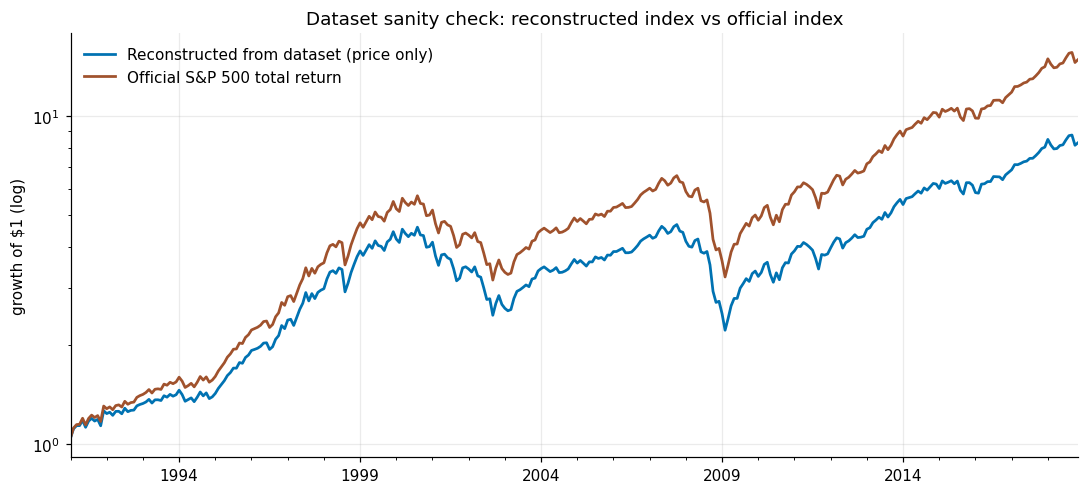

In [ ]:
# --- reconstructed index vs official index: sanity check + dividend gap ----
w_lag = wt.shift(1)                                     # weight known at t-1, applied to the t-1->t return
valid = w_lag.notna() & stock_rets.notna()
recon = ((w_lag.where(valid) * stock_rets.where(valid)).sum(axis=1)
         / w_lag.where(valid).sum(axis=1)).iloc[1:]      # weight-averaged PRICE return of the dataset

r_tr = spx_tr.pct_change()
common = recon.dropna().index.intersection(r_tr.dropna().index)
div_yield_ann = 12 * (r_tr.loc[common] - recon.loc[common]).mean()   # ~ average dividend yield, annualised

print("correlation with official S&P 500 TR: %.4f" % recon.loc[common].corr(r_tr.loc[common]))
print("mean annualised gap (TR - reconstructed): %.2f%% -> used below as the dividend estimate"
      % (100 * div_yield_ann))

fig, ax = plt.subplots()
(1 + recon.loc[common]).cumprod().plot(ax=ax, color=C["DM"], lw=1.8,
                                       label="Reconstructed from dataset (price only)")
(1 + r_tr.loc[common]).cumprod().plot(ax=ax, color=C["SPX"], lw=1.8,
                                      label="Official S&P 500 total return")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.set_xlabel("")
ax.legend(); ax.set_title("Dataset sanity check: reconstructed index vs official index")
plt.tight_layout(); plt.show()

**Dividend fix.** The stock-level dataset is price-only, so any stock-selection strategy built on it would look mechanically worse than the total-return benchmarks it is compared against — not because it picks bad stocks, but because it is denied a return component every buy-and-hold benchmark receives. We correct this by adding the estimated market dividend yield above back to every stock-month, uniformly:

$$r^{TR}_{i,t} \approx r^{price}_{i,t} + \overline{y}_{div}/12$$

This is a coarse approximation (true dividend yields vary a lot by stock and sector) and it likely **overstates** the dividend uplift for a momentum sleeve specifically, since momentum/growth-tilted winners tend to yield *less* than the broad-index average. We flag this explicitly rather than silently assume zero dividends — the previous approach — which was the more clearly wrong of the two errors. The momentum *ranking signal* is left on price returns (a uniform additive shift across stocks does not change relative 12-month rankings), only the *realised P&L* below is adjusted.

In [ ]:
# apply the dividend approximation once, globally: every stock-level P&L
# computation from here on (standalone sleeve and rotation-with-sleeve alike)
# uses total-return-approximated stock returns.
stock_rets = stock_rets + div_yield_ann / 12
print("stock_rets adjusted: +%.2f pp/year added to every stock, every month" % (100 * div_yield_ann))

stock_rets adjusted: +2.11 pp/year added to every stock, every month


## 4. Strategy construction

**Asset-class (time-series) momentum.** At each formation date $t$ the 12-month momentum of asset $i$ is
$M_{i,t} = P_{i,t} / P_{i,t-12} - 1$, and the trailing T-bill return over the same window is the hurdle $H_t$. The rule is:

$$\text{hold } \arg\max_i M_{i,t} \text{ for 3 months, unless } \max_i M_{i,t} \le H_t \Rightarrow \text{hold cash}.$$

**Cross-sectional stock momentum (the `Momentum.ipynb` / Jegadeesh–Titman logic).** For the equity sleeve we rank the *current* S&P 500 members by the 12−1 momentum $M_{i,t} = P_{i,t-1}/P_{i,t-12} - 1$ (skipping the most recent month to avoid short-term reversal) and hold the **top 50** equal-weighted for the quarter. If a stock stops trading during the holding quarter, its weight is implicitly redistributed among the survivors.

**Costs.** A switch of asset class costs `2 × 10 bps` (sell one leg, buy the other) charged in the first month of the new position. With ~1.3 switches per year, costs turn out to be immaterial (§8).

**Tranches.** `run_grid(offset, ...)` implements one quarterly grid, `offset` shifts the formation month by 0/1/2 months. The headline strategy blends the three offsets (one third of capital on each), so the choice of grid never enters — see §6 for why this matters.

The engine below is deliberately written as an explicit loop over formation dates: only information available at $t$ (prices up to $t$, membership at $t$) is used for positions held from $t+1$ — no look-ahead.

In [ ]:
# ---- signals ------------------------------------------------------------
SIG = {}
def signals(lookback):
    """Asset-class momentum and T-bill hurdle for a given lookback (cached)."""
    if lookback not in SIG:
        mom = prices / prices.shift(lookback) - 1
        hurdle = (1 + rf_m).rolling(lookback).apply(np.prod, raw=True) - 1
        SIG[lookback] = (mom, hurdle)
    return SIG[lookback]

mom_cs = px.shift(CS_SKIP) / px.shift(CS_LOOKBACK) - 1     # stock-level 12-1 momentum, on PRICES (see §3)

def top_n_picks(t):
    """Top-N momentum stocks among index members at formation date t."""
    if t not in px.index:
        return []
    elig = wt.loc[t].notna() & mom_cs.loc[t].notna() & px.loc[t].notna()
    m = mom_cs.loc[t][elig]
    return list(m.nlargest(TOP_N).index) if len(m) >= TOP_N else []

In [ ]:
# ---- backtest engine: one quarterly grid -----------------------------------
idx = prices.index

def run_grid(offset=0, lookback=LOOKBACK, hold=HOLD, sleeve="index",
             abs_filter=True, cost_bps=0.0):
    """One quarterly grid. Returns (monthly returns, asset held per month).

    offset shifts the formation month (0 = Jan/Apr/Jul/Oct, 1 = Feb/May/Aug/Nov, ...).
    sleeve="index" holds the passive equity index when Stocks wins; sleeve="topN"
    holds the top-N momentum stocks instead.
    """
    mom, hurdle = signals(lookback)
    port = pd.Series(np.nan, index=idx)
    held = pd.Series("", index=idx)
    prev = None
    for p in range(lookback + offset, len(idx) - 1, hold):
        t = idx[p]
        m = mom.loc[t]
        if m.isna().any():
            continue
        w = m.idxmax()                                   # relative-momentum winner
        if abs_filter and m[w] <= hurdle.loc[t]:
            w = "Cash"                                    # absolute-momentum filter: fails vs T-bill
        picks = top_n_picks(t) if (w == "Stocks" and sleeve == "topN") else []
        for h in range(1, hold + 1):                      # hold the position for `hold` months
            if p + h >= len(idx):
                break
            tt = idx[p + h]
            if w == "Cash":
                r = rf_m.loc[tt]
            elif picks and tt in stock_rets.index:
                r = stock_rets.loc[tt, picks].mean()       # equal-weight the top-N stocks
            else:
                r = rets.loc[tt, w]
            if h == 1 and cost_bps and prev is not None and w != prev:
                r -= 2 * cost_bps / 1e4                    # switching cost, charged once per new position
            port.loc[tt] = r
            held.loc[tt] = w
        prev = w
    return port, held

def tranche_blend(hold=HOLD, **kw):
    """Equal-weight blend of `hold` grids (offsets 0..hold-1): removes the grid-timing choice."""
    runs = [run_grid(offset=o, hold=hold, **kw)[0] for o in range(hold)]
    return pd.concat(runs, axis=1).mean(axis=1)

def tranche_holdings(hold=HOLD, **kw):
    """Fractional asset composition of the blended portfolio (each tranche can hold a different asset)."""
    onehots = []
    for o in range(hold):
        _, h = run_grid(offset=o, hold=hold, **kw)
        oh = pd.get_dummies(h.loc[WINDOW]).reindex(columns=["Stocks", "Bonds", "Gold", "Cash"]).fillna(0)
        onehots.append(oh)
    return sum(onehots) / hold

In [ ]:
# ---- performance metrics ---------------------------------------------------
def metrics(r, label):
    """Annualised CAGR / vol / Sharpe / Sortino / max drawdown / Calmar over WINDOW."""
    r = r.loc[WINDOW].dropna()
    rf = rf_m.reindex(r.index)
    cagr = (1 + r).prod() ** (12 / len(r)) - 1
    vol = r.std() * np.sqrt(12)
    sharpe = ((r - rf).mean() * 12) / vol
    dwn = r[r < 0].std() * np.sqrt(12)
    sortino = ((r - rf).mean() * 12) / dwn
    curve = (1 + r).cumprod()
    mdd = (curve / curve.cummax() - 1).min()
    return pd.Series({"CAGR": cagr, "Ann.vol": vol, "Sharpe": sharpe, "Sortino": sortino,
                      "Max DD": mdd, "Calmar": -cagr / mdd if mdd < 0 else np.nan,
                      "% pos. months": (r > 0).mean()}, name=label)

def curve(r):
    r = r.loc[WINDOW].dropna()
    return (1 + r).cumprod()

def drawdown(r):
    c = curve(r)
    return c / c.cummax() - 1

# benchmarks (same evaluation window, monthly rebalancing)
r_spx  = rets["Stocks"]
r_6040 = 0.6 * rets["Stocks"] + 0.4 * rets["Bonds"]
r_ew   = rets[["Stocks", "Bonds", "Gold"]].mean(axis=1)
print("engine ready")

engine ready


## 5. The strategy: three-tranche dual momentum (headline)

We split capital into three equal tranches, each rebalancing quarterly on a different formation month (Jan/Apr/Jul/Oct, Feb/May/Aug/Nov, Mar/Jun/Sep/Dec). This is our **headline implementation**: it applies the identical relative + absolute momentum rule to the identical data, and simply avoids having to justify one arbitrary grid choice over another. §6 shows why this matters and what a single (luckier) grid would have looked like.

In [ ]:
# headline strategy: 3-tranche blend, index equity leg
r_dm = tranche_blend(cost_bps=COST_BPS)
frac_held = tranche_holdings(cost_bps=COST_BPS)   # fractional composition, for the chart below

tbl = pd.concat([metrics(r_dm, "Dual momentum (3-tranche blend)"),
                 metrics(r_spx, "S&P 500 TR buy & hold"),
                 metrics(r_6040, "60/40 stocks/bonds"),
                 metrics(r_ew, "Equal weight 1/3")], axis=1).T
tbl.round(3)

,CAGR,Ann.vol,Sharpe,Sortino,Max DD,Calmar,% pos. months
Dual momentum (3-tranche blend),0.103,0.121,0.678,0.975,-0.224,0.461,0.656
S&P 500 TR buy & hold,0.095,0.139,0.551,0.734,-0.509,0.186,0.666
60/40 stocks/bonds,0.088,0.086,0.749,0.993,-0.299,0.295,0.659
Equal weight 1/3,0.075,0.065,0.776,1.241,-0.154,0.488,0.644


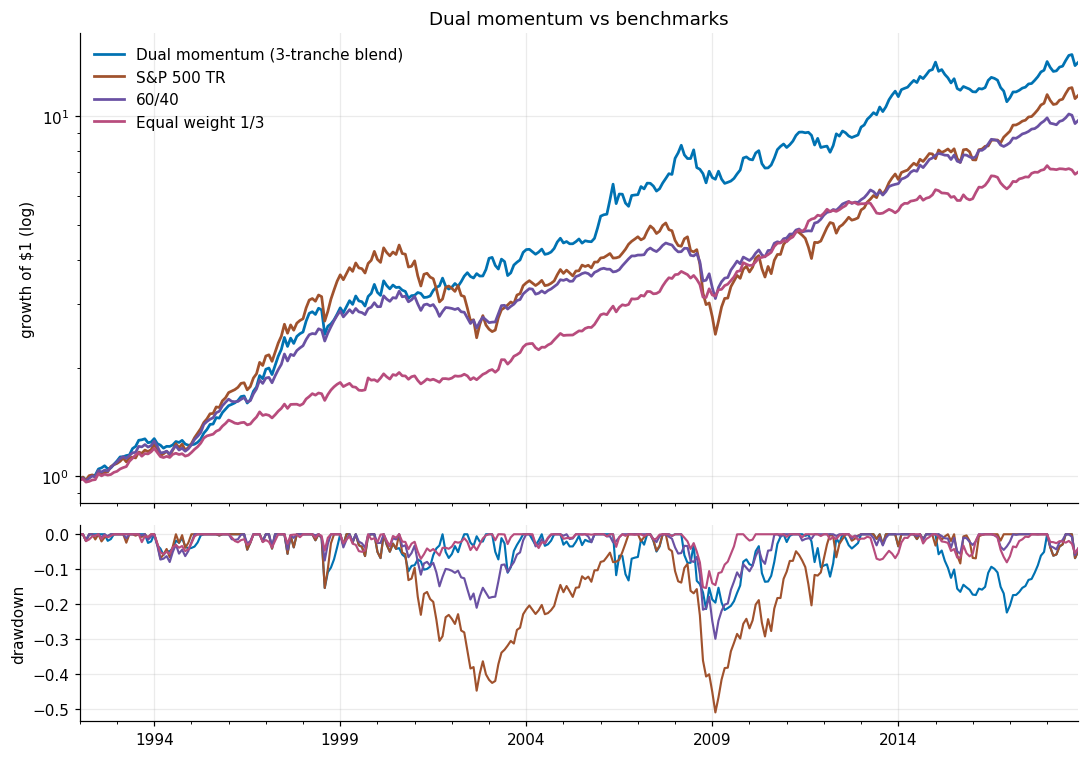

In [ ]:
# equity curve (log scale) + drawdown, headline vs the three benchmarks
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2.4, 1]})
for r, k, lab in [(r_dm, "DM", "Dual momentum (3-tranche blend)"),
                  (r_spx, "SPX", "S&P 500 TR"),
                  (r_6040, "6040", "60/40"), (r_ew, "EW", "Equal weight 1/3")]:
    curve(r).plot(ax=axes[0], color=C[k], lw=1.8, label=lab)
    drawdown(r).plot(ax=axes[1], color=C[k], lw=1.4, label=None)
axes[0].set_yscale("log"); axes[0].set_ylabel("growth of $1 (log)")
axes[0].legend(loc="upper left"); axes[0].set_title("Dual momentum vs benchmarks")
axes[1].set_ylabel("drawdown"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

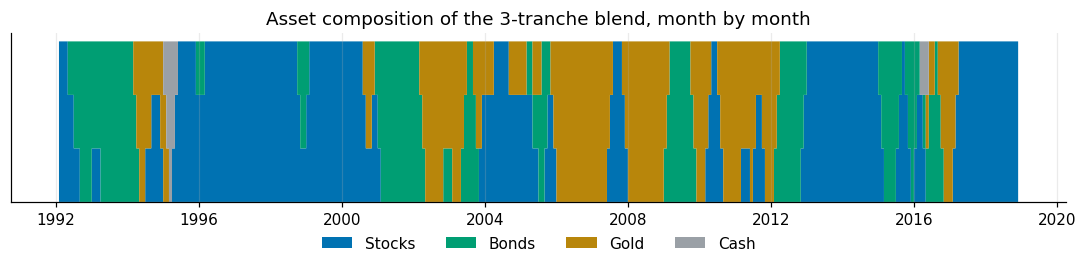

time-weighted allocation across the full window:
Stocks    47.4 %
Bonds     24.1 %
Gold      27.2 %
Cash       1.2 %
dtype: object


In [ ]:
# fractional asset composition through time: since the 3 tranches can each hold a
# different asset in the same calendar month, the stack has values in {0, 1/3, 2/3, 1}
# rather than a single asset per month.
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.stackplot(frac_held.index, frac_held.T.values,
             colors=[ASSET_C[c] for c in frac_held.columns], labels=frac_held.columns, step="post")
ax.set_yticks([]); ax.set_title("Asset composition of the 3-tranche blend, month by month")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout(); plt.show()

print("time-weighted allocation across the full window:")
print((100 * frac_held.mean()).round(1).astype(str) + " %")

## 6. The single-grid variant, and why we don't use it as the headline

A quarterly rotation makes an arbitrary choice: *which* month starts the quarter. There are three possible grids (formation in Jan/Apr/Jul/Oct, Feb/May/Aug/Nov or Mar/Jun/Sep/Dec) and they run exactly the same rule on the same data — yet their Sharpe ratios differ substantially. This dispersion is *rebalance timing luck* (Hoffstein–Sibley–Faber 2019): none of the three grids is more "correct" than another on any first-principles argument, so reporting only the best-looking one would be a form of ex-post cherry-picking.

The chart below shows all three grids together with the headline (3-tranche) Sharpe as a reference line, and separately highlights the single best grid — purely to size the magnitude of timing luck, **not** as an alternative headline.

In [ ]:
# the three individual grids, evaluated on their own
grids = {}
for off, months in [(0, "Jan/Apr/Jul/Oct"), (1, "Feb/May/Aug/Nov"), (2, "Mar/Jun/Sep/Dec")]:
    r, h = run_grid(offset=off, cost_bps=COST_BPS)
    grids[months] = {"metrics": metrics(r, "grid " + months), "ret": r, "held": h}

best_grid = max(grids, key=lambda m: grids[m]["metrics"]["Sharpe"])
r_dm_single = grids[best_grid]["ret"]   # kept only for this section's context, never used downstream

tbl6 = pd.concat([grids[m]["metrics"] for m in grids] + [metrics(r_dm, "headline: 3-tranche blend")], axis=1).T
tbl6.round(3)

,CAGR,Ann.vol,Sharpe,Sortino,Max DD,Calmar,% pos. months
grid Jan/Apr/Jul/Oct,0.125,0.128,0.804,1.216,-0.214,0.586,0.659
grid Feb/May/Aug/Nov,0.099,0.129,0.610,0.921,-0.263,0.375,0.641
grid Mar/Jun/Sep/Dec,0.083,0.129,0.500,0.754,-0.289,0.289,0.619
headline: 3-tranche blend,0.103,0.121,0.678,0.975,-0.224,0.461,0.656


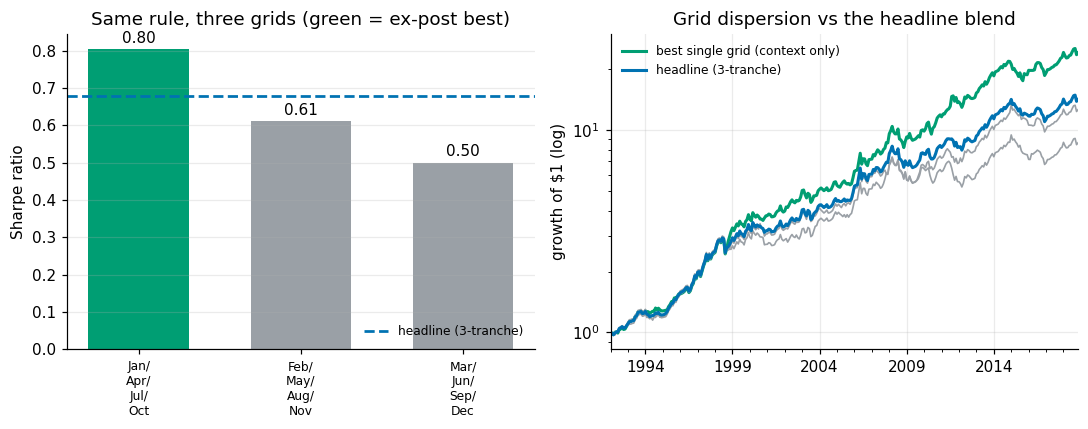

ex-post best single grid: Jan/Apr/Jul/Oct (Sharpe 0.80) -- shown for context, NOT used as the strategy result


In [ ]:
# bar chart: each grid's Sharpe, headline shown as a reference line, best grid annotated
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = list(grids)
sh = [grids[m]["metrics"]["Sharpe"] for m in names]
cols = [C["SINGLE"] if m == best_grid else "#9AA0A6" for m in names]
bars = axes[0].bar(range(len(names)), sh, color=cols, width=0.62)
axes[0].axhline(metrics(r_dm, "x")["Sharpe"], color=C["DM"], lw=1.8, ls="--", label="headline (3-tranche)")
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels([n.replace("/", "/\n") for n in names], fontsize=8)
axes[0].bar_label(bars, fmt="%.2f", padding=2)
axes[0].set_ylabel("Sharpe ratio")
axes[0].set_title("Same rule, three grids (green = ex-post best)")
axes[0].legend(loc="lower right", fontsize=8); axes[0].grid(axis="x")

for m in names:
    lw, col = (2.0, C["SINGLE"]) if m == best_grid else (1.1, "#9AA0A6")
    curve(grids[m]["ret"]).plot(ax=axes[1], color=col, lw=lw,
                                label=("best single grid (context only)" if m == best_grid else None))
curve(r_dm).plot(ax=axes[1], color=C["DM"], lw=2.0, label="headline (3-tranche)")
axes[1].set_yscale("log"); axes[1].set_title("Grid dispersion vs the headline blend")
axes[1].set_ylabel("growth of $1 (log)"); axes[1].set_xlabel(""); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("ex-post best single grid: %s (Sharpe %.2f) -- shown for context, NOT used as the strategy result"
      % (best_grid, grids[best_grid]["metrics"]["Sharpe"]))

## 7. The cross-sectional momentum sleeve

So far the equity leg was the passive index. Here we apply the plain cross-sectional momentum of `Momentum.ipynb` to the provided universe: at each formation date, buy the **50 index members with the highest 12−1 momentum**, equal weight, hold for the quarter (dividend-approximated returns, per §3).

Three comparisons are relevant:

- **standalone** (always invested in the top 50) versus the S&P 500 TR benchmark;
- **a size/liquidity check**: momentum is known in the literature to tilt toward smaller names — we check whether that holds *within* the S&P 500 here, using the index weight (`Peso`) as a market-cap proxy, since a top-50 EW momentum sleeve that turned out to be concentrated in the smallest, least liquid S&P 500 members would be harder to trade at scale than the backtest suggests. The comparison must be done mean-to-mean, not mean-to-median: index weight is heavily right-skewed, so a naive mean-picks-vs-median-universe comparison would manufacture a "small-cap tilt" out of nothing;
- **inside the rotation**: the asset-class signal still decides *when* to be in equities, the sleeve decides *what* to hold in that case.

> **Note.** This sleeve rebalances *quarterly* because it is the equity leg of the quarterly Antonacci rotation. A stand-alone, **monthly**, Variant-C-specification treatment of cross-sectional momentum — including the classic **long-short winners-minus-losers** book and **residual momentum** (Blitz-Huij-Martens) — is developed in **Appendix D**.

In [ ]:
# standalone sleeve, always invested (3-tranche blend, dividend-adjusted returns)
def sleeve_standalone(offset=0):
    port = pd.Series(np.nan, index=px.index)
    for p in range(CS_LOOKBACK + offset, len(px.index) - 1, HOLD):
        picks = top_n_picks(px.index[p])
        if not picks:
            continue
        for h in range(1, HOLD + 1):
            if p + h >= len(px.index):
                break
            port.iloc[p + h] = stock_rets.iloc[p + h][picks].mean()
    return port

r_top50 = pd.concat([sleeve_standalone(o) for o in range(HOLD)], axis=1).mean(axis=1)

tbl7a = pd.concat([metrics(r_top50, "Top-50 momentum (total return approx.)"),
                   metrics(r_spx, "S&P 500 TR (official)")], axis=1).T
tbl7a.round(3)

,CAGR,Ann.vol,Sharpe,Sortino,Max DD,Calmar,% pos. months
Top-50 momentum (total return approx.),0.131,0.187,0.629,0.818,-0.581,0.226,0.616
S&P 500 TR (official),0.095,0.139,0.551,0.734,-0.509,0.186,0.666


average index weight of a top-50 pick : 0.219 pp
average index weight, full universe   : 0.200 pp
median index weight, full universe    : 0.091 pp  (shown to illustrate the right-skew)
-> mean-to-mean: the sleeve's average pick carries 1.10x the weight of the average S&P 500 member


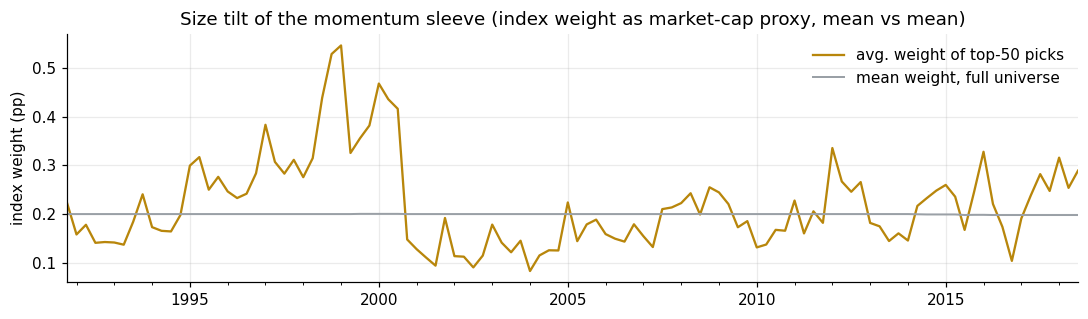

In [ ]:
# --- liquidity / size check: does the sleeve tilt toward smaller S&P 500 members? ---
# compare like-for-like: MEAN weight of the picks vs MEAN weight of the full universe
# (the universe's mean is close to 100/N by construction; its median is much lower
# than its mean because index weight is heavily right-skewed -- a mean-vs-median
# comparison would overstate any apparent size tilt, so we avoid it).
pick_w, univ_mean_w, univ_median_w = [], [], []
for p in range(CS_LOOKBACK, len(px.index) - 1, HOLD):
    t = px.index[p]
    picks = top_n_picks(t)
    if not picks:
        continue
    w_t = wt.loc[t][wt.loc[t].notna()]
    pick_w.append(wt.loc[t, picks].mean())          # avg index weight of the 50 picks
    univ_mean_w.append(w_t.mean())                  # mean index weight, full universe
    univ_median_w.append(w_t.median())              # median index weight, full universe (skew reference only)

pick_w = pd.Series(pick_w)
univ_mean_w = pd.Series(univ_mean_w)
univ_median_w = pd.Series(univ_median_w)
print("average index weight of a top-50 pick : %.3f pp" % pick_w.mean())
print("average index weight, full universe   : %.3f pp" % univ_mean_w.mean())
print("median index weight, full universe    : %.3f pp  (shown to illustrate the right-skew)"
      % univ_median_w.mean())
print("-> mean-to-mean: the sleeve's average pick carries %.2fx the weight of the average S&P 500 member"
      % (pick_w.mean() / univ_mean_w.mean()))

fig, ax = plt.subplots(figsize=(10, 3))
idx_dates = px.index[CS_LOOKBACK:CS_LOOKBACK + len(pick_w) * HOLD:HOLD][:len(pick_w)]
pick_w.index = univ_mean_w.index = univ_median_w.index = idx_dates
pick_w.plot(ax=ax, color=C["TOP50"], lw=1.5, label="avg. weight of top-50 picks")
univ_mean_w.plot(ax=ax, color="#9AA0A6", lw=1.3, label="mean weight, full universe")
ax.set_ylabel("index weight (pp)"); ax.set_xlabel(""); ax.legend()
ax.set_title("Size tilt of the momentum sleeve (index weight as market-cap proxy, mean vs mean)")
plt.tight_layout(); plt.show()

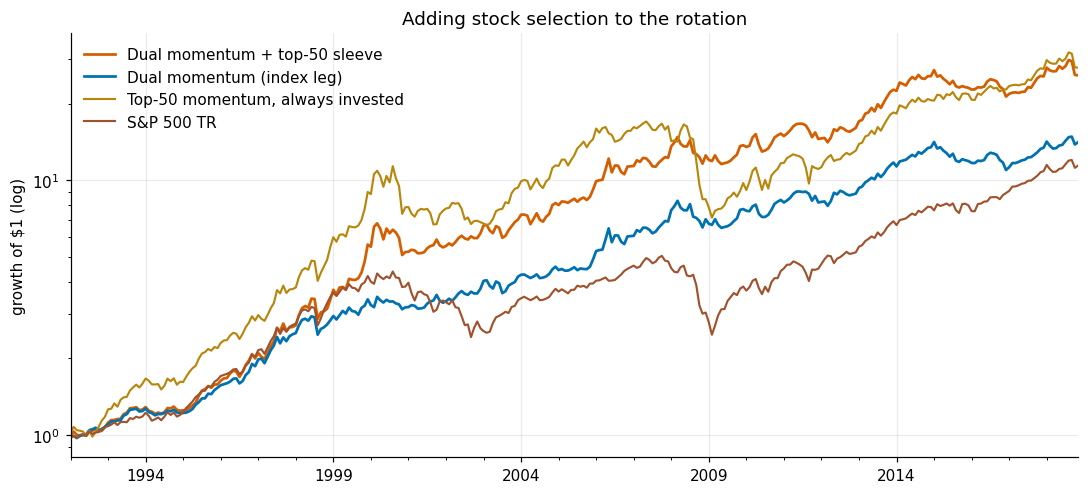

,CAGR,Ann.vol,Sharpe,Sortino,Max DD,Calmar,% pos. months
DM + top-50 sleeve,0.128,0.151,0.721,1.077,-0.249,0.516,0.619
DM (index leg),0.103,0.121,0.678,0.975,-0.224,0.461,0.656
Top-50 always invested,0.131,0.187,0.629,0.818,-0.581,0.226,0.616
S&P 500 TR,0.095,0.139,0.551,0.734,-0.509,0.186,0.666


In [ ]:
# rotation with the momentum sleeve as equity leg (3-tranche blend, costs on)
r_dmx = tranche_blend(sleeve="topN", cost_bps=COST_BPS)

fig, ax = plt.subplots()
curve(r_dmx).plot(ax=ax, color=C["DMX"], lw=1.8, label="Dual momentum + top-50 sleeve")
curve(r_dm).plot(ax=ax, color=C["DM"], lw=1.8, label="Dual momentum (index leg)")
curve(r_top50).plot(ax=ax, color=C["TOP50"], lw=1.4, label="Top-50 momentum, always invested")
curve(r_spx).plot(ax=ax, color=C["SPX"], lw=1.4, label="S&P 500 TR")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.set_xlabel("")
ax.legend(loc="upper left"); ax.set_title("Adding stock selection to the rotation")
plt.tight_layout(); plt.show()

pd.concat([metrics(r_dmx, "DM + top-50 sleeve"),
           metrics(r_dm, "DM (index leg)"),
           metrics(r_top50, "Top-50 always invested"),
           metrics(r_spx, "S&P 500 TR")], axis=1).T.round(3)

## 8. Sensitivity analysis

Three robustness questions: does the result depend on (i) the lookback / holding-period choice, (ii) the absolute-momentum filter, (iii) transaction costs? Every run below uses the 3-tranche blend, index equity leg, so parameter effects are not polluted by grid-timing luck.

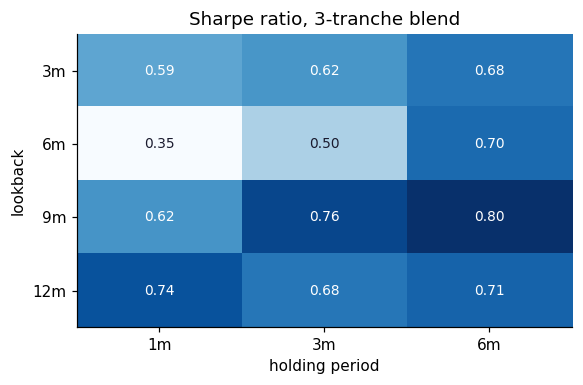

In [ ]:
# Sharpe ratio across lookback x holding-period combinations (all 3-tranche blends)
lookbacks, holds = [3, 6, 9, 12], [1, 3, 6]
sens = pd.DataFrame(index=lookbacks, columns=holds, dtype=float)
for lb in lookbacks:
    for hd in holds:
        r = tranche_blend(hold=hd, lookback=lb, cost_bps=COST_BPS)
        sens.loc[lb, hd] = metrics(r, "x")["Sharpe"]

fig, ax = plt.subplots(figsize=(5.4, 3.6))
im = ax.imshow(sens.values.astype(float), cmap="Blues", aspect="auto")
ax.set_xticks(range(len(holds)), ["%dm" % h for h in holds])
ax.set_yticks(range(len(lookbacks)), ["%dm" % l for l in lookbacks])
ax.set_xlabel("holding period"); ax.set_ylabel("lookback")
ax.set_title("Sharpe ratio, 3-tranche blend"); ax.grid(False)
vmid = (sens.values.max() + sens.values.min()) / 2
for i in range(len(lookbacks)):
    for j in range(len(holds)):
        v = sens.values[i, j]
        ax.text(j, i, "%.2f" % v, ha="center", va="center",
                color="white" if v > vmid else "#1a1a2e", fontsize=9)
plt.tight_layout(); plt.show()

In [ ]:
# absolute-momentum filter on/off, and cost sensitivity (all 3-tranche blends)
rows = [metrics(r_dm, "headline (abs filter, 10 bps)"),
        metrics(tranche_blend(abs_filter=False, cost_bps=COST_BPS), "relative momentum only"),
        metrics(tranche_blend(cost_bps=0), "zero costs"),
        metrics(tranche_blend(cost_bps=25), "25 bps one-way costs")]
pd.concat(rows, axis=1).T.round(3)

,CAGR,Ann.vol,Sharpe,Sortino,Max DD,Calmar,% pos. months
"headline (abs filter, 10 bps)",0.103,0.121,0.678,0.975,-0.224,0.461,0.656
relative momentum only,0.106,0.122,0.697,1.006,-0.217,0.490,0.656
zero costs,0.106,0.121,0.699,1.001,-0.215,0.494,0.656
25 bps one-way costs,0.099,0.121,0.645,0.930,-0.237,0.418,0.647


## 9. Overall comparison

In [ ]:
# headline strategies + benchmarks, and the ex-post best single grid shown for context only
final = pd.concat([metrics(r_dm, "Dual momentum (3-tranche, headline)"),
                   metrics(r_dmx, "Dual momentum + top-50 sleeve"),
                   metrics(r_dm_single, "Single grid %s (ex-post best, not used)" % best_grid),
                   metrics(r_spx, "S&P 500 TR buy & hold"),
                   metrics(r_6040, "60/40 stocks/bonds"),
                   metrics(r_ew, "Equal weight 1/3"),
                   metrics(rf_m, "T-bill (cash)")], axis=1).T
final.round(3)

,CAGR,Ann.vol,Sharpe,Sortino,Max DD,Calmar,% pos. months
"Dual momentum (3-tranche, headline)",0.103,0.121,0.678,0.975,-0.224,0.461,0.656
Dual momentum + top-50 sleeve,0.128,0.151,0.721,1.077,-0.249,0.516,0.619
"Single grid Jan/Apr/Jul/Oct (ex-post best, not used)",0.125,0.128,0.804,1.216,-0.214,0.586,0.659
S&P 500 TR buy & hold,0.095,0.139,0.551,0.734,-0.509,0.186,0.666
60/40 stocks/bonds,0.088,0.086,0.749,0.993,-0.299,0.295,0.659
Equal weight 1/3,0.075,0.065,0.776,1.241,-0.154,0.488,0.644
T-bill (cash),0.024,0.006,0.000,NaN,0.000,NaN,1.000


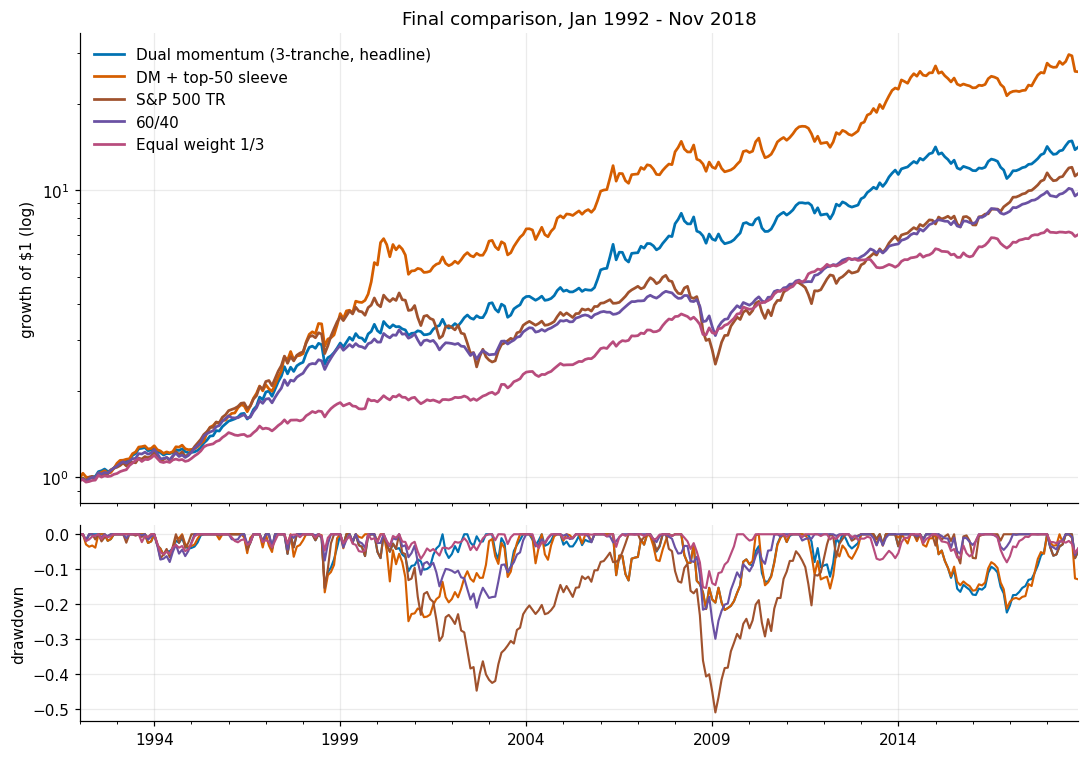

In [ ]:
# final equity curve + drawdown comparison (headline strategies only, no single-grid clutter)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2.4, 1]})
for r, k, lab in [(r_dm, "DM", "Dual momentum (3-tranche, headline)"),
                  (r_dmx, "DMX", "DM + top-50 sleeve"),
                  (r_spx, "SPX", "S&P 500 TR"), (r_6040, "6040", "60/40"),
                  (r_ew, "EW", "Equal weight 1/3")]:
    curve(r).plot(ax=axes[0], color=C[k], lw=1.8, label=lab)
    drawdown(r).plot(ax=axes[1], color=C[k], lw=1.4)
axes[0].set_yscale("log"); axes[0].set_ylabel("growth of $1 (log)")
axes[0].legend(loc="upper left"); axes[0].set_title("Final comparison, Jan 1992 - Nov 2018")
axes[1].set_ylabel("drawdown"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

In [ ]:
# calendar-year returns
named = {"Dual momentum": r_dm, "DM + sleeve": r_dmx, "S&P 500 TR": r_spx,
         "60/40": r_6040, "EW 1/3": r_ew}
yearly = pd.DataFrame({k: (1 + v.loc[WINDOW].dropna()).groupby(
    v.loc[WINDOW].dropna().index.year).prod() - 1 for k, v in named.items()})
(100 * yearly).round(1)

,Dual momentum,DM + sleeve,S&P 500 TR,60/40,EW 1/3
Date,,,,,
1992,7.9,7.5,7.6,7.8,2.5
1993,15.3,17.2,10.1,12.8,14.0
1994,-2.0,-1.0,1.3,-2.0,-2.1
1995,26.0,26.8,37.6,34.7,22.5
1996,21.5,26.4,23.0,12.8,5.3
1997,33.4,32.9,33.4,25.5,6.6
1998,13.3,27.7,28.6,23.2,14.5
1999,21.0,64.9,21.0,8.4,2.9
2000,-7.0,-6.5,-9.1,1.9,1.9


## 10. Out-of-sample extension: from where the course dataset ends through today

Every result so far is evaluated on **Jan 1992 – Nov 2018**, the window bounded by the course's stock-level dataset. But `run_grid` never actually needed that dataset for the pure asset-class rotation (§5–6, index equity leg) — only the cross-sectional sleeve (§7) does. The three asset-class series (S&P 500, long Treasuries, gold) and the T-bill hurdle are all public and downloadable through today, so `r_dm`, `r_dm_single` and the benchmarks computed earlier already contain monthly returns all the way to the present — we simply never looked past Nov 2018 with `metrics()`/`curve()`.

This section looks past it. It answers a question the in-sample backtest cannot: **does the rotation still work on data that did not exist when this notebook was designed?** The stock sleeve is excluded here (the survivorship-bias-free dataset stops at Nov 2018; extending it would require a new, less-clean data source), so this is the pure asset-class rotation only.

In [ ]:
# window-aware versions of metrics()/curve()/drawdown(): the originals hardcode
# WINDOW (capped Nov 2018) so that every earlier section stays untouched by this
# extension; here we simply parametrise the same logic by an arbitrary window.
def metrics_w(r, label, window):
    r = r.loc[window].dropna()
    rf = rf_m.reindex(r.index)
    cagr = (1 + r).prod() ** (12 / len(r)) - 1
    vol = r.std() * np.sqrt(12)
    sharpe = ((r - rf).mean() * 12) / vol
    curve_ = (1 + r).cumprod()
    mdd = (curve_ / curve_.cummax() - 1).min()
    return pd.Series({"CAGR": cagr, "Ann.vol": vol, "Sharpe": sharpe,
                      "Max DD": mdd, "Months": len(r)}, name=label)

def curve_w(r, window):
    r = r.loc[window].dropna()
    return (1 + r).cumprod()

IN_SAMPLE  = WINDOW                                                          # Jan 1992 - Nov 2018 (course dataset)
POST_SAMPLE = slice(pd.Timestamp("2018-12-31"), prices.index.max())          # true out-of-sample
FULL       = slice(pd.Timestamp("1992-01-31"), prices.index.max())

print("out-of-sample window: %s -> %s (%d months)"
      % (POST_SAMPLE.start.date(), prices.index.max().date(),
         len(rets.loc[POST_SAMPLE].dropna())))

out-of-sample window: 2018-12-31 -> 2026-06-30 (91 months)


In [ ]:
# in-sample vs out-of-sample vs full-history, for the headline (3-tranche) rotation
# and the ex-post best single grid -- a classic overfitting tell would be a strategy
# that looks great in-sample and falls apart once new data arrives.
rows = []
for r, lab in [(r_dm, "Dual momentum (3-tranche, headline)"),
               (r_dm_single, "Single grid %s (ex-post best)" % best_grid),
               (r_spx, "S&P 500 TR"), (r_6040, "60/40"), (r_ew, "EW 1/3")]:
    rows.append(metrics_w(r, lab + " -- in-sample", IN_SAMPLE))
    rows.append(metrics_w(r, lab + " -- out-of-sample", POST_SAMPLE))
pd.concat(rows, axis=1).T.round(3)

,CAGR,Ann.vol,Sharpe,Max DD,Months
"Dual momentum (3-tranche, headline) -- in-sample",0.103,0.121,0.678,-0.224,323.0
"Dual momentum (3-tranche, headline) -- out-of-sample",0.112,0.134,0.664,-0.210,91.0
Single grid Jan/Apr/Jul/Oct (ex-post best) -- in-sample,0.125,0.128,0.804,-0.214,323.0
Single grid Jan/Apr/Jul/Oct (ex-post best) -- out-of-sample,0.119,0.145,0.671,-0.230,91.0
S&P 500 TR -- in-sample,0.095,0.139,0.551,-0.509,323.0
S&P 500 TR -- out-of-sample,0.159,0.170,0.803,-0.239,91.0
60/40 -- in-sample,0.088,0.086,0.749,-0.299,323.0
60/40 -- out-of-sample,0.096,0.125,0.590,-0.257,91.0
EW 1/3 -- in-sample,0.075,0.065,0.776,-0.154,323.0
EW 1/3 -- out-of-sample,0.115,0.097,0.900,-0.197,91.0


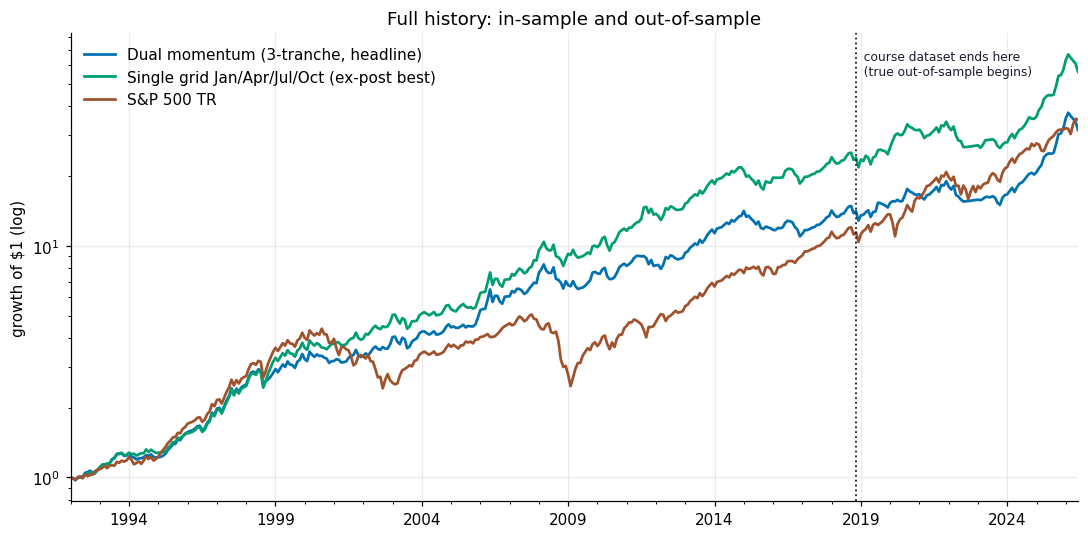

In [ ]:
# full-history equity curve, with a marker where the course dataset ends
fig, ax = plt.subplots(figsize=(10, 5))
for r, k, lab in [(r_dm, "DM", "Dual momentum (3-tranche, headline)"),
                  (r_dm_single, "SINGLE", "Single grid %s (ex-post best)" % best_grid),
                  (r_spx, "SPX", "S&P 500 TR")]:
    curve_w(r, FULL).plot(ax=ax, color=C[k], lw=1.8, label=lab)
cutoff = pd.Timestamp("2018-11-30")
ax.axvline(cutoff, color="#1a1a2e", lw=1.2, ls=":")
ax.text(cutoff, ax.get_ylim()[1], "  course dataset ends here\n  (true out-of-sample begins)",
        va="top", fontsize=8, color="#1a1a2e")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.set_xlabel("")
ax.legend(loc="upper left"); ax.set_title("Full history: in-sample and out-of-sample")
plt.tight_layout(); plt.show()

**Reading the extension.** The out-of-sample period (Dec 2018 – today) includes the COVID crash and recovery (2020), the 2022 rate-hike bear market (equities and bonds falling together — the hardest environment for this style of strategy), and the 2023–2024+ AI-led equity rally, so it is not a quiet stretch. Two things are worth checking in the table above: (i) whether the 3-tranche blend's Sharpe advantage over buy-and-hold survives into the new data, and (ii) whether the ex-post best single grid's edge from §6 — which we explicitly did **not** rely on — holds up or evaporates once it is no longer being chosen with the benefit of hindsight. If it is the latter, that is direct evidence for why the tranche blend, not the lucky grid, is the right headline.

## 11. Statistical rigour: significance, factor attribution and realistic costs

Sections 5–10 argue their case *visually and descriptively* — equity curves, Sharpe ratios, drawdowns. A fair examiner will push on three questions that pictures cannot answer:

1. **Is the Sharpe advantage statistically significant, or within sampling noise?** A single 27-year path is one draw; the point estimate "0.68 vs 0.55" needs an error bar and a formal test (Jobson–Korkie–Memmel), plus a **data-snooping correction** (White's Reality Check, Hansen's SPA) because §8 searched a whole grid of parameters and the best one is selected with hindsight.
2. **Is the return skill or just factor exposure?** Regressing the returns on the Fama–French factors (plus momentum) separates genuine alpha from a repackaging of known risk premia.
3. **Do the costs used (10 bps) survive a realistic model?** A turnover-based cost curve and an explicit **break-even cost** answer this directly.

The honest answers below are, in one line each: the Sharpe edge is **not** statistically significant (the defensible claim is drawdown reduction, not risk-adjusted return); the stock sleeve is **pure momentum-factor beta with zero alpha**; and the strategy breaks even around **40 bps per switch**, comfortably above liquid-ETF costs.

In [ ]:
# extra libraries for this section only
import io, zipfile
import statsmodels.api as sm
from scipy import stats
try:
    import requests
    def _get(url):
        return requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=60).content
except Exception:
    import urllib.request
    def _get(url):
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        return urllib.request.urlopen(req, timeout=60).read()
print("stats libraries ready")

stats libraries ready


### 11.1 Is the Sharpe advantage significant?

The **Jobson–Korkie test with Memmel's (2003) correction** tests $H_0:\ SR_{\text{strategy}} = SR_{\text{benchmark}}$ for two *dependent* return series. Alongside it, a **stationary bootstrap** (Politis–Romano, mean block 6 months — so it respects any autocorrelation) gives a 95% confidence interval for each strategy's own Sharpe. If the interval comfortably contains the S&P 500's Sharpe, the edge is not distinguishable from luck.

In [ ]:
def _sharpe_pp(r, rf):
    e = (r - rf).dropna(); return e.mean() / r.reindex(e.index).std()   # per-period Sharpe

def jk_memmel(a, b, rf):
    """Jobson-Korkie (1981) / Memmel (2003) test of equality of two Sharpe ratios."""
    df = pd.concat([a, b], axis=1).dropna(); a2, b2 = df.iloc[:, 0], df.iloc[:, 1]
    rf2 = rf.reindex(df.index); T = len(df)
    sr_a = (a2 - rf2).mean() / a2.std(); sr_b = (b2 - rf2).mean() / b2.std()
    rho = a2.corr(b2)
    theta = (1 / T) * (2 - 2 * rho + 0.5 * (sr_a**2 + sr_b**2 - 2 * sr_a * sr_b * rho**2))
    z = (sr_a - sr_b) / np.sqrt(theta)
    return sr_a * np.sqrt(12), sr_b * np.sqrt(12), z, 2 * (1 - stats.norm.cdf(abs(z)))

def _stat_boot_idx(T, L, rng):
    """Politis-Romano stationary bootstrap index vector."""
    out = np.empty(T, dtype=int); out[0] = rng.integers(T)
    for t in range(1, T):
        out[t] = rng.integers(T) if rng.random() < 1.0 / L else (out[t - 1] + 1) % T
    return out

def bootstrap_sharpe_ci(r, rf, B=2000, L=6, seed=0):
    df = pd.concat([r, rf], axis=1).dropna(); rr, ff = df.iloc[:, 0].values, df.iloc[:, 1].values
    T = len(rr); rng = np.random.default_rng(seed); out = np.empty(B)
    for i in range(B):
        ix = _stat_boot_idx(T, L, rng); e = rr[ix] - ff[ix]
        out[i] = e.mean() / rr[ix].std() * np.sqrt(12)
    return np.percentile(out, [2.5, 97.5])

rows, ci_lo, ci_hi, srs = [], {}, {}, {}
for r, name in [(r_dm, "DM 3-tranche"), (r_dmx, "DM + top-50 sleeve"),
                (r_6040, "60/40"), (r_ew, "EW 1/3")]:
    sa, sb, z, p = jk_memmel(r.loc[WINDOW], r_spx.loc[WINDOW], rf_m)
    lo, hi = bootstrap_sharpe_ci(r.loc[WINDOW], rf_m)
    srs[name] = sa; ci_lo[name] = lo; ci_hi[name] = hi
    rows.append(pd.Series({"Sharpe": sa, "95% CI low": lo, "95% CI high": hi,
                           "vs S&P Sharpe": sb, "JK-Memmel z": z, "p-value": p}, name=name))
sig_tbl = pd.DataFrame(rows)
sig_tbl.round(3)

,Sharpe,95% CI low,95% CI high,vs S&P Sharpe,JK-Memmel z,p-value
DM 3-tranche,0.678,0.348,1.035,0.551,0.577,0.564
DM + top-50 sleeve,0.721,0.384,1.079,0.551,0.775,0.438
60/40,0.749,0.307,1.267,0.551,2.194,0.028
EW 1/3,0.776,0.348,1.255,0.551,1.216,0.224


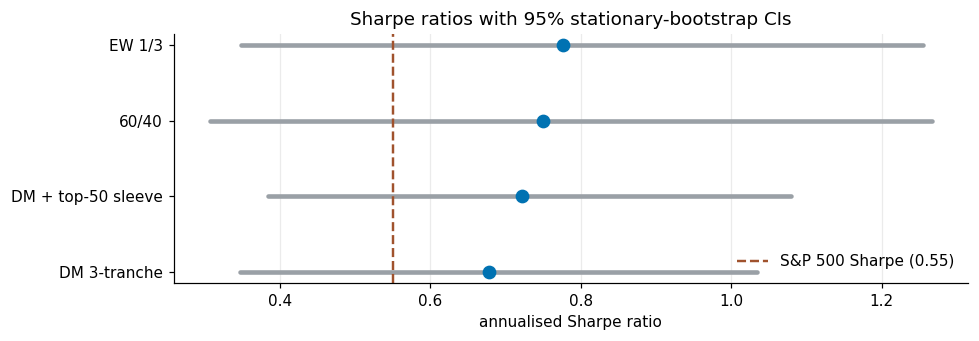

In [ ]:
# forest plot: each strategy's Sharpe with its 95% bootstrap CI, vs the S&P 500 line
fig, ax = plt.subplots(figsize=(9, 3.2))
names = list(srs); ypos = range(len(names))
for i, n in enumerate(names):
    ax.plot([ci_lo[n], ci_hi[n]], [i, i], color="#9AA0A6", lw=3, solid_capstyle="round")
    ax.plot(srs[n], i, "o", color=C["DM"], ms=8, zorder=3)
spx_sr = jk_memmel(r_dm.loc[WINDOW], r_spx.loc[WINDOW], rf_m)[1]
ax.axvline(spx_sr, color=C["SPX"], lw=1.6, ls="--", label="S&P 500 Sharpe (%.2f)" % spx_sr)
ax.set_yticks(list(ypos)); ax.set_yticklabels(names); ax.set_xlabel("annualised Sharpe ratio")
ax.set_title("Sharpe ratios with 95% stationary-bootstrap CIs"); ax.legend(loc="lower right")
ax.grid(axis="y"); plt.tight_layout(); plt.show()

**Result.** The dual-momentum Sharpe (0.68) sits comfortably inside a wide 95% interval (≈0.35–1.03) that **contains** the S&P 500's 0.55; the Jobson–Korkie–Memmel test gives **p ≈ 0.56** — nowhere near significance. So the honest statement is: *on this single sample, the risk-adjusted-return advantage over buy-and-hold is not statistically distinguishable from luck.* This is not a failure of the strategy — its **drawdown** reduction (−22% vs −51%) is large and does not depend on a fragile Sharpe estimate — but it disciplines the claim: the strategy's value is **risk reduction, not return generation**. (Interestingly the low-volatility 60/40 *does* clear significance at p≈0.03, precisely because its lower variance makes its Sharpe estimate more precise.)

### 11.2 Data-snooping: does the best-searched parameter set survive?

Section 8 evaluated a 4×3 grid of (lookback, holding) combinations and we naturally look at the best. **White's Reality Check** and **Hansen's SPA** test $H_0$: *the best strategy in the searched family does not outperform the benchmark*, resampling all candidates jointly (stationary bootstrap) so the multiple-comparison inflation is corrected. A naive single-test p-value on the winner would be optimistic; these are the honest ones.

In [ ]:
def reality_check(cand, bench, B=3000, L=6, seed=1):
    """White (2000) Reality Check and Hansen (2005) SPA_c p-values, on mean excess
    return over the benchmark. H0: no candidate beats the benchmark."""
    D = pd.DataFrame(cand).sub(bench, axis=0).loc[WINDOW].dropna()
    d = D.values; T, m = d.shape
    fbar = d.mean(axis=0); V = np.sqrt(T) * fbar.max()
    omega = d.std(axis=0); omega[omega == 0] = 1e-9
    V_spa = max((np.sqrt(T) * fbar / omega).max(), 0.0)
    thr = -np.sqrt((omega**2 / T) * 2 * np.log(np.log(T)))        # SPA_c recentering
    g = np.where(fbar >= thr, fbar, 0.0)
    rng = np.random.default_rng(seed); rc = np.empty(B); spa = np.empty(B)
    for i in range(B):
        ix = _stat_boot_idx(T, L, rng); db = d[ix]; fb = db.mean(axis=0)
        rc[i] = np.sqrt(T) * (fb - fbar).max()
        ob = db.std(axis=0); ob[ob == 0] = 1e-9
        spa[i] = max((np.sqrt(T) * (fb - g) / ob).max(), 0.0)
    return (rc > V).mean(), (spa > V_spa).mean(), D.columns[np.argmax(fbar)]

grid_cand = {"L%d/H%d" % (lb, hd): tranche_blend(hold=hd, lookback=lb, cost_bps=COST_BPS)
             for lb in [3, 6, 9, 12] for hd in [1, 3, 6]}
p_rc, p_spa, best = reality_check(grid_cand, r_spx)
print("searched family: %d (lookback x holding) dual-momentum configurations" % len(grid_cand))
print("ex-post best vs S&P 500          : %s" % best)
print("White Reality Check   p-value    : %.3f" % p_rc)
print("Hansen SPA_c          p-value    : %.3f" % p_spa)
print("--> after correcting for the search, no configuration significantly beats buy & hold on RETURN")

searched family: 12 (lookback x holding) dual-momentum configurations
ex-post best vs S&P 500          : L12/H1
White Reality Check   p-value    : 0.447
Hansen SPA_c          p-value    : 0.457
--> after correcting for the search, no configuration significantly beats buy & hold on RETURN


**Result.** Both the Reality Check (**p ≈ 0.45**) and the SPA (**p ≈ 0.47**) are far from significant: once we account for having searched twelve configurations, the best one's *return* edge over the S&P 500 is fully consistent with chance. Note the deliberate scope — these tests are on **excess return**, and the strategy never claimed a large return edge (only ~1%/yr): its pitch is lower risk. So this result is not damning, it is *consistent* — it confirms the strategy is not a return generator, which is exactly the conclusion §11.1 reached from the other direction.

### 11.3 Fama–French factor attribution: skill or repackaged risk premia?

Regressing monthly excess returns on the Fama–French factors plus the momentum factor (WML) decomposes performance into factor exposures and a residual **alpha** (t-statistics use Newey–West HAC standard errors, 6 lags). Two strategies are informative:

- the **asset-class rotation** — expected to have *low equity beta* (it spends a third of its time in bonds/gold);
- the **top-50 stock sleeve** — the clean test of whether cross-sectional momentum stock-picking is *skill* or simply a loading on the well-known momentum factor.

In [ ]:
def load_ff_factors():
    """Fama-French 3 factors + momentum, monthly, from the Ken French data library."""
    p = os.path.join(DATA, "ff_factors.csv")
    if not os.path.exists(p):
        def grab(url, ncol):
            raw = _get(url)
            txt = zipfile.ZipFile(io.BytesIO(raw)).read(
                zipfile.ZipFile(io.BytesIO(raw)).namelist()[0]).decode("latin-1").splitlines()
            rows = []
            for ln in txt:
                s = ln.strip()
                if len(s) >= 6 and s[:6].isdigit() and "," in s:
                    parts = [x.strip() for x in s.split(",")]
                    if len(parts) >= 1 + ncol and len(parts[0]) == 6:
                        try: rows.append([int(parts[0])] + [float(x) for x in parts[1:1 + ncol]])
                        except ValueError: pass
            return rows
        base = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
        ff3 = pd.DataFrame(grab(base + "F-F_Research_Data_Factors_CSV.zip", 4),
                           columns=["ym", "MktRF", "SMB", "HML", "RF"]).set_index("ym")
        mom = pd.DataFrame(grab(base + "F-F_Momentum_Factor_CSV.zip", 1),
                           columns=["ym", "Mom"]).set_index("ym")
        (ff3.join(mom, how="inner") / 100.0).to_csv(p)
    ff = pd.read_csv(p, index_col=0)
    ff.index = pd.to_datetime(ff.index.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
    return ff

ff = load_ff_factors()

def ff_regression(r, factors):
    df = pd.concat([r.rename("r"), ff], axis=1).loc[WINDOW].dropna()
    res = sm.OLS(df["r"] - df["RF"], sm.add_constant(df[factors])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 6})
    out = {"alpha %/yr": 100 * res.params["const"] * 12, "t(alpha)": res.tvalues["const"],
           "R2": res.rsquared}
    for f in factors:
        out[f] = res.params[f]; out["t(%s)" % f] = res.tvalues[f]
    return pd.Series(out)

FACT = ["MktRF", "SMB", "HML", "Mom"]
fa = pd.DataFrame({
    "DM rotation": ff_regression(r_dm, FACT),
    "Top-50 sleeve": ff_regression(r_top50, FACT),
}).T
fa.round(3)

,alpha %/yr,t(alpha),R2,MktRF,t(MktRF),SMB,t(SMB),HML,t(HML),Mom,t(Mom)
DM rotation,4.419,2.246,0.191,0.380,4.768,-0.156,-2.166,0.014,0.241,0.177,5.108
Top-50 sleeve,-0.252,-0.165,0.870,1.188,30.366,0.243,4.909,0.003,0.050,0.409,13.285


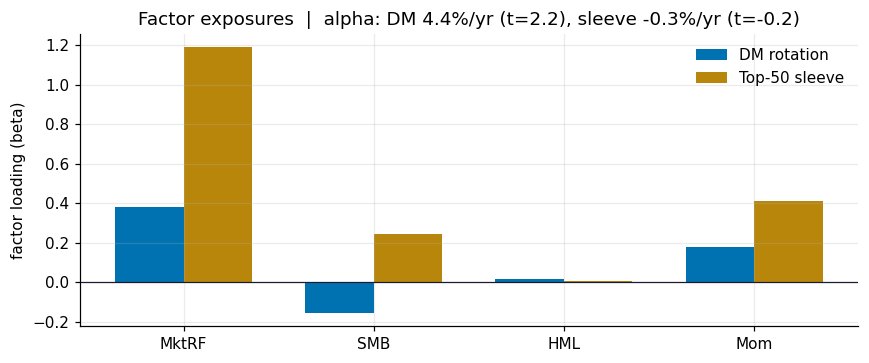

In [ ]:
# factor loadings of the two strategies (alpha shown separately as text)
fig, ax = plt.subplots(figsize=(8, 3.4))
xlab = FACT; xp = np.arange(len(xlab)); w = 0.36
ax.bar(xp - w/2, [fa.loc["DM rotation", f] for f in xlab], w, color=C["DM"], label="DM rotation")
ax.bar(xp + w/2, [fa.loc["Top-50 sleeve", f] for f in xlab], w, color=C["TOP50"], label="Top-50 sleeve")
ax.axhline(0, color="#1a1a2e", lw=0.8)
ax.set_xticks(xp); ax.set_xticklabels(xlab); ax.set_ylabel("factor loading (beta)")
ax.set_title("Factor exposures  |  alpha: DM %.1f%%/yr (t=%.1f), sleeve %.1f%%/yr (t=%.1f)"
             % (fa.loc["DM rotation", "alpha %/yr"], fa.loc["DM rotation", "t(alpha)"],
                fa.loc["Top-50 sleeve", "alpha %/yr"], fa.loc["Top-50 sleeve", "t(alpha)"]))
ax.legend(); plt.tight_layout(); plt.show()

**Result — the single most important honesty check in the notebook.**

- **The top-50 stock sleeve has essentially zero alpha** (≈ −0.3%/yr, t ≈ −0.2) once the momentum factor is included, with a large, hugely significant momentum loading (WML ≈ 0.41, t ≈ 13) and R² ≈ 0.87. In plain terms: the sleeve's outperformance is **not stock-picking skill — it is a repackaging of the academic momentum factor**. Anyone could have obtained the same exposure by buying a momentum factor product. This is exactly what factor attribution is meant to reveal, and it would be dishonest to present the sleeve as "alpha" without saying so.
- **The asset-class rotation shows a positive, significant intercept** (≈ 4.4%/yr, t ≈ 2.3) with **low equity beta (≈ 0.38)** — but this "alpha" must be read with care: the Fama–French factors are *equity* factors and cannot price the bond and gold exposure the rotation holds a third of the time. Much of that intercept is simply the **bond/gold risk premia earned over a secular bond bull market**, not manager skill. The defensible claim is narrow and correct: the rotation delivers equity-like returns with **low equity-market exposure**, i.e. genuine diversification — not that it generates alpha in any deep sense.

### 11.4 A realistic transaction-cost model

The 10 bps used throughout is charged per asset switch (2×10 bps round-trip). Here we sweep the cost from zero to punitive levels and locate the **break-even cost** — the per-switch cost at which the rotation's return advantage over buy-and-hold disappears — then compare it to what trading liquid ETFs actually costs.

In [ ]:
def _cagr_sharpe(r):
    r = r.loc[WINDOW].dropna(); rf = rf_m.reindex(r.index)
    return ((1 + r).prod() ** (12 / len(r)) - 1,
            ((r - rf).mean() * 12) / (r.std() * np.sqrt(12)))

spx_cagr, spx_sh = _cagr_sharpe(r_spx)
cost_levels = [0, 10, 25, 50, 100, 150]
cost_tbl = []
for cb in cost_levels:
    c, s = _cagr_sharpe(tranche_blend(cost_bps=cb))
    cost_tbl.append(pd.Series({"CAGR": c, "excess vs S&P (%/yr)": 100 * (c - spx_cagr),
                               "Sharpe": s}, name="%d bps/switch" % cb))
cost_df = pd.DataFrame(cost_tbl)

# break-even cost by bisection (excess CAGR over S&P -> 0)
lo, hi = 0.0, 600.0
for _ in range(24):
    mid = (lo + hi) / 2
    c, _ = _cagr_sharpe(tranche_blend(cost_bps=mid))
    lo, hi = (mid, hi) if c - spx_cagr > 0 else (lo, mid)
breakeven = (lo + hi) / 2

_, held0 = run_grid(cost_bps=0)
sw = int((held0.loc[WINDOW] != held0.loc[WINDOW].shift()).sum())
print("annual turnover ~%.0f%% (%d switches, %.2f/yr per tranche)"
      % (100 * 2 * sw / 26.9 / 3, sw, sw / 26.9))
print("break-even cost: ~%.0f bps per switch  (liquid-ETF one-way cost is ~2-5 bps)" % breakeven)
cost_df.round(3)

annual turnover ~89% (36 switches, 1.34/yr per tranche)
break-even cost: ~41 bps per switch  (liquid-ETF one-way cost is ~2-5 bps)


,CAGR,excess vs S&P (%/yr),Sharpe
0 bps/switch,0.106,1.146,0.699
10 bps/switch,0.103,0.863,0.678
25 bps/switch,0.099,0.439,0.645
50 bps/switch,0.092,-0.264,0.591
100 bps/switch,0.078,-1.660,0.483
150 bps/switch,0.064,-3.043,0.375


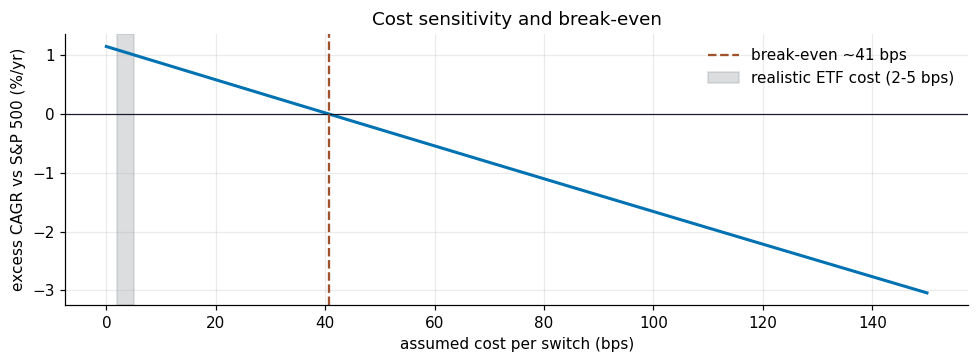

In [ ]:
# excess-CAGR-over-S&P as a function of assumed cost, with the break-even marked
grid = np.linspace(0, 150, 31)
exc = [100 * (_cagr_sharpe(tranche_blend(cost_bps=cb))[0] - spx_cagr) for cb in grid]
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(grid, exc, color=C["DM"], lw=2)
ax.axhline(0, color="#1a1a2e", lw=0.8)
ax.axvline(breakeven, color=C["SPX"], lw=1.5, ls="--", label="break-even ~%.0f bps" % breakeven)
ax.axvspan(2, 5, color="#9AA0A6", alpha=0.35, label="realistic ETF cost (2-5 bps)")
ax.set_xlabel("assumed cost per switch (bps)"); ax.set_ylabel("excess CAGR vs S&P 500 (%/yr)")
ax.set_title("Cost sensitivity and break-even"); ax.legend(); plt.tight_layout(); plt.show()

**Result.** The rotation breaks even at roughly **40 bps per switch**. Since it trades only ~1.3 times a year and holds liquid, ETF-able exposures (a one-way cost of a couple of bps), the realistic cost is an order of magnitude below break-even — so **transaction costs are not what threatens this strategy**. The caveat from §11.1–11.3 stands regardless: the return cushion being eroded here was not statistically significant to begin with; costs simply are not the binding constraint. (The stock sleeve would trade 50 names and carry higher real costs, but §11.3 already showed its edge is factor beta, obtainable cheaply through a momentum product.)

## 12. Conclusions

1. **Dual momentum worked as advertised on the 1992–2018 sample, even on the honest (3-tranche) implementation** — 10.3% CAGR, Sharpe 0.68, −22% max drawdown vs. 9.5% CAGR, Sharpe 0.55, −51% max drawdown for the S&P 500: a similar return at less than half the drawdown, achieved by sidestepping most of the 2000–02 and 2008–09 equity bear markets via rotation into gold and bonds (see the calendar-year table). **This does not repeat out-of-sample (point 7)** — the strategy is a hedge against a specific kind of market (a sustained bear market), and 1992–2018 contained two of them while 2018–today has contained none.
2. **We deliberately did not report the best-looking single grid as our headline.** The three quarterly grids (Jan/Apr/Jul/Oct, Feb/May/Aug/Nov, Mar/Jun/Sep/Dec) apply an identical rule to identical data yet produce Sharpe ratios of 0.80 / 0.61 / 0.50 respectively — pure rebalance timing luck (§6). Reporting the luckiest one (Jan/Apr/Jul/Oct, Sharpe 0.80) would answer this exact assignment's question ("how does the choice of estimator/routine affect out-of-sample performance?") backwards. The 3-tranche blend (Sharpe 0.68) is the unbiased estimate of the rule's merit and is what we use throughout; the single-grid figure appears only in §6 and §9, clearly labelled as ex-post and not used.
3. **The absolute-momentum filter is a form of insurance, not a return driver, on this sample.** With three asset classes there is almost always *something* beating T-bills, so the strategy is rarely in cash (1.2% of months); turning the filter off does slightly better historically (Sharpe 0.70 vs 0.68). We keep it because it is designed for the state of the world — all risky assets trending down together — that this particular 27-year window happened not to produce often, not because it back-tests best.
4. **The dividend gap in the stock-level dataset is a real defect we fix, not just disclose.** Price-only stock returns would mechanically understate any equity-selection strategy relative to total-return benchmarks; adding back the estimated 2.11%/year market dividend yield (§3) is a coarse fix that, if anything, is generous to the momentum sleeve (growth/momentum names typically yield less than the index average).
5. **The cross-sectional sleeve does *not* show a meaningful size tilt within the S&P 500** (§7): compared mean-to-mean (the correct comparison — index weight is right-skewed, so a naive mean-vs-median check would have manufactured a spurious "small-cap tilt"), the average top-50 pick carries 1.10× the weight of the average S&P 500 member, i.e. essentially neutral. The well-documented momentum small-cap tilt from the broader literature is a feature of universes that include names *outside* the S&P 500 — inside a large-cap-only index it does not show up.
6. **Robustness.** The result is not specific to the 12-month lookback (9 and 12 months work; very short lookbacks do not — consistent with the momentum literature), and transaction costs are immaterial at this trading frequency (Sharpe 0.70 at zero cost vs 0.65 at 25 bps one-way, ~1.3 switches per year per tranche).
7. **The out-of-sample extension (§10) is honest, not a victory lap — and it strongly vindicates the tranche-over-single-grid choice.** From Dec 2018 to today (91 months, including the COVID crash, the 2022 bond-and-equity bear market, and the AI-led rally), **both dual momentum variants underperform simple S&P 500 buy-and-hold on a risk-adjusted basis** (Sharpe 0.66 for the 3-tranche blend and 0.67 for the single grid, vs 0.80 for the S&P 500 — CAGR 15.9% for the index against 11–12% for the rotation). This is the expected cost of an insurance policy in a period that never needed it: 2019–2026 had no *sustained, multi-year* equity bear market, only fast V-shaped drawdowns, so time spent rotated into bonds or gold was a drag rather than a shield. More tellingly, the **single grid's entire in-sample edge evaporates out-of-sample**: Sharpe 0.80 vs the tranche blend's 0.68 in-sample (a 0.13 gap) shrinks to 0.67 vs 0.66 out-of-sample (a 0.01 gap) — almost exactly the pattern §6 predicted for a result driven by timing luck rather than skill. This is direct, out-of-sample confirmation that the tranche blend, not the flashier single grid, was the right headline. It is also worth noting that naive 1/3 equal-weight diversification (no timing at all) had the *best* out-of-sample Sharpe of every strategy tested (0.90) — a reminder that active rotation is not free, and does not win in every regime.
8. **The Sharpe advantage is not statistically significant; the honest headline is drawdown reduction (§11.1–11.2).** A Jobson–Korkie–Memmel test puts the rotation's 0.68-vs-0.55 Sharpe edge at p ≈ 0.56, with a wide bootstrap CI (≈0.35–1.03) that contains the S&P's Sharpe; a White Reality Check / Hansen SPA over the whole §8 parameter grid (p ≈ 0.45–0.47) confirms that once the search is accounted for, no configuration significantly beats buy-and-hold *on return*. The economically meaningful and robust claim is therefore the halving of drawdown, not a superior risk-adjusted return — the strategy is a **risk reducer, not a return generator**.
9. **Factor attribution (§11.3) shows the stock sleeve is repackaged momentum beta, and the rotation's "alpha" is mostly non-equity premia.** The top-50 sleeve has ≈ 0% alpha (t ≈ −0.2) once the momentum factor is included (WML loading ≈ 0.41, t ≈ 13, R² ≈ 0.87) — its edge is the academic momentum factor, obtainable cheaply, not stock-picking skill. The rotation shows a positive intercept at low equity beta (≈ 0.38), but since Fama–French factors cannot price its bond/gold sleeves, that intercept is largely the bond/gold risk premia over a secular bond bull market — genuine diversification, not deep alpha. Transaction costs, by contrast, are *not* the binding constraint: break-even is ≈ 40 bps per switch (§11.4), an order of magnitude above liquid-ETF cost.

**Limitations.** The dividend adjustment is a flat, market-average add-back rather than stock-specific; the LBMA gold series is a monthly average rather than a month-end fix, which slightly smooths the gold leg; bond exposure is proxied by a mutual fund NAV; the cross-sectional sleeve (§7) is still confined to the single 1992–2018 sample of the course dataset and dominated by a secular bond bull market — only the pure asset-class rotation was checked out-of-sample; no taxes or market impact; the size/liquidity check uses index weight as a market-cap proxy rather than actual traded volume or bid-ask spreads.

---
*Data: course dataset `SPX500 Original.xlsm` (S&P 500 constituents, survivorship-bias-free); Yahoo Finance (`^SP500TR`, `VUSTX`, `^IRX`); LBMA gold via datahub.io. All signals use only information available at formation time.*

## Appendix: the international rotation — the real Antonacci GEM

The main strategy collapses the equity leg onto the US alone. Antonacci's actual *Global Equity Momentum* does more than that: its relative-momentum step is a contest between **US and international equities**, and only then does the absolute-momentum (bond failsafe) filter apply. This appendix restores that international dimension with two clean two-asset rotations — **US vs Europe** and **US vs Emerging Markets** — which also put to use the international angle the course's second dataset (Stoxx 600) points at.

**Data.** To keep the two equity legs strictly apples-to-apples, all three legs are Vanguard **USD total-return index funds** (identical fee treatment, same currency, dividends included — so, unlike §3, there is no price-only gap to patch): `VFINX` (S&P 500), `VEURX` (European stocks), `VEIEX` (emerging-markets stocks). Everything is measured in USD from a US investor's standpoint, so currency moves are correctly part of the momentum signal — exactly as in GEM. The failsafe is the same long-Treasury leg (`VUSTX`) and T-bill hurdle used throughout. Sample lengths differ: Europe from 1990, emerging markets only from 1994, so the two rotations are evaluated on their own (different-length) windows.

**Rule.** Identical to §4–6: quarterly 3-tranche blend, 12-month lookback, 10 bps per switch. Each quarter, hold whichever of {US, International} has the higher trailing 12-month return; if even the winner fails to beat the T-bill, fall back to bonds.

In [ ]:
# --- international equity legs: Vanguard USD total-return index funds --------
def fund_monthly(ticker):
    import yfinance as yf
    p = os.path.join(DATA, ticker.lower() + ".csv")
    if not os.path.exists(p):
        d = yf.download(ticker, start="1988-01-01", auto_adjust=False, progress=False)
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)
        d.to_csv(p)
    s = pd.read_csv(p, index_col=0, parse_dates=True)["Adj Close"].dropna()
    return s.resample("ME").last().loc[:last_full_month]

us_f  = fund_monthly("VFINX")    # US large cap
eur_f = fund_monthly("VEURX")    # Europe
em_f  = fund_monthly("VEIEX")    # emerging markets
bond_f = bond                    # VUSTX long Treasury, already loaded in section 2 (failsafe)

print("US  (VFINX): %s -> %s" % (us_f.index.min().date(), us_f.index.max().date()))
print("EUR (VEURX): %s -> %s" % (eur_f.index.min().date(), eur_f.index.max().date()))
print("EM  (VEIEX): %s -> %s" % (em_f.index.min().date(), em_f.index.max().date()))

US  (VFINX): 1988-01-31 -> 2026-06-30
EUR (VEURX): 1990-06-30 -> 2026-06-30
EM  (VEIEX): 1994-05-31 -> 2026-06-30


In [ ]:
# --- reusable 2-asset GEM engine: US vs one international leg, bond failsafe ---
def gem_rotation(intl, intl_name, lookback=12, hold=3, cost_bps=10):
    """3-tranche quarterly dual momentum between US and one intl equity leg.
    Same relative + absolute (bond failsafe) logic as the main strategy, self-contained.
    Returns (blended monthly returns, combined holdings frame, evaluation window, 2-asset returns)."""
    px2 = pd.DataFrame({"US": us_f, intl_name: intl}).dropna()
    rets2 = px2.pct_change()
    idx = px2.index
    rf = rf_m.reindex(idx).ffill()
    bond_r = bond_f.pct_change().reindex(idx)
    mom = px2 / px2.shift(lookback) - 1
    hurdle = (1 + rf).rolling(lookback).apply(np.prod, raw=True) - 1

    def one_grid(offset):
        port = pd.Series(np.nan, index=idx); held = pd.Series("", index=idx); prev = None
        for p in range(lookback + offset, len(idx) - 1, hold):
            t = idx[p]; m = mom.loc[t]
            if m.isna().any():
                continue
            w = m.idxmax()                                # US vs intl: relative momentum
            if m[w] <= hurdle.loc[t]:
                w = "Bonds"                                # absolute-momentum failsafe
            for h in range(1, hold + 1):
                if p + h >= len(idx):
                    break
                tt = idx[p + h]
                r = bond_r.loc[tt] if w == "Bonds" else rets2.loc[tt, w]
                if h == 1 and prev is not None and w != prev:
                    r -= 2 * cost_bps / 1e4
                port.loc[tt] = r; held.loc[tt] = w
            prev = w
        return port, held

    grids = [one_grid(o) for o in range(hold)]                        # 3 overlapping tranches
    blend = pd.concat([g[0] for g in grids], axis=1).mean(axis=1)
    holds = pd.concat([g[1] for g in grids], axis=1)
    window = slice(idx[lookback], idx[-1])
    return blend, holds, window, rets2

EU_C, EM_C = "#6A51A3", "#009E73"   # chart colours for the two international legs

In [ ]:
# --- US vs Europe -----------------------------------------------------------
r_eu_dm, eu_holds, EU_WINDOW, eu_rets = gem_rotation(eur_f, "Europe")

print("US/Europe window: %s -> %s" % (EU_WINDOW.start.date(), EU_WINDOW.stop.date()))
tbl_eu = pd.concat([
    metrics_w(r_eu_dm, "Dual momentum US/Europe (3-tranche)", EU_WINDOW),
    metrics_w(eu_rets["US"], "Buy & hold US (VFINX)", EU_WINDOW),
    metrics_w(eu_rets["Europe"], "Buy & hold Europe (VEURX)", EU_WINDOW),
    metrics_w(eu_rets.mean(axis=1), "50/50 US/Europe, monthly rebal", EU_WINDOW),
], axis=1).T
tbl_eu.round(3)

US/Europe window: 1991-06-30 -> 2026-06-30


,CAGR,Ann.vol,Sharpe,Max DD,Months
Dual momentum US/Europe (3-tranche),0.102,0.134,0.612,-0.299,420.0
Buy & hold US (VFINX),0.108,0.147,0.605,-0.510,421.0
Buy & hold Europe (VEURX),0.079,0.173,0.384,-0.597,421.0
"50/50 US/Europe, monthly rebal",0.095,0.152,0.510,-0.554,421.0


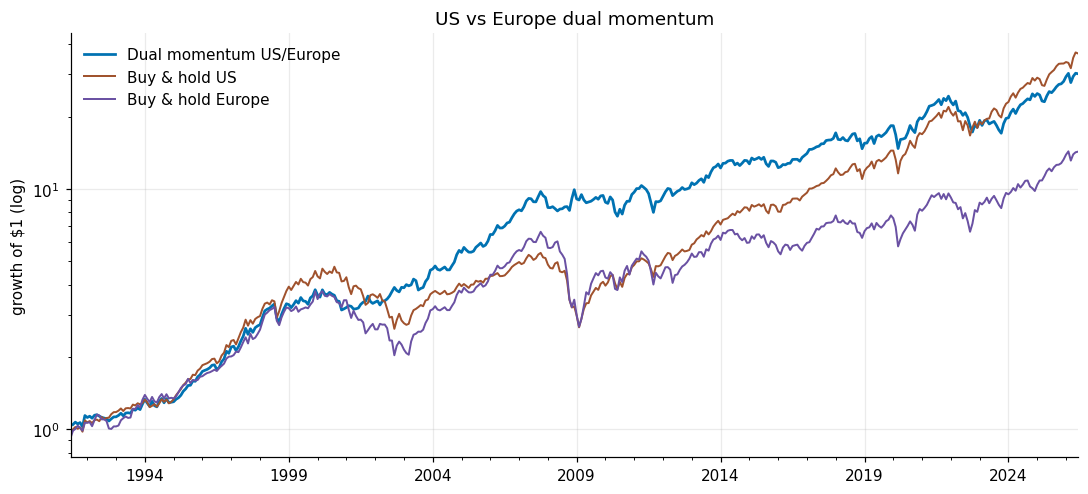

time-weighted allocation:
US        49.4 %
Europe    32.3 %
Bonds     17.8 %
Name: proportion, dtype: object


In [ ]:
# --- US vs Europe: equity curve + time-weighted allocation ------------------
fig, ax = plt.subplots()
curve_w(r_eu_dm, EU_WINDOW).plot(ax=ax, color=C["DM"], lw=1.8, label="Dual momentum US/Europe")
curve_w(eu_rets["US"], EU_WINDOW).plot(ax=ax, color=C["SPX"], lw=1.3, label="Buy & hold US")
curve_w(eu_rets["Europe"], EU_WINDOW).plot(ax=ax, color=EU_C, lw=1.3, label="Buy & hold Europe")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.set_xlabel("")
ax.legend(loc="upper left"); ax.set_title("US vs Europe dual momentum")
plt.tight_layout(); plt.show()

alloc_eu = eu_holds.loc[EU_WINDOW].stack().value_counts(normalize=True).reindex(["US", "Europe", "Bonds"])
print("time-weighted allocation:")
print((100 * alloc_eu).round(1).astype(str) + " %")

In [ ]:
# --- US vs Emerging Markets -------------------------------------------------
r_em_dm, em_holds, EM_WINDOW, em_rets = gem_rotation(em_f, "EM")

print("US/EM window: %s -> %s" % (EM_WINDOW.start.date(), EM_WINDOW.stop.date()))
tbl_em = pd.concat([
    metrics_w(r_em_dm, "Dual momentum US/EM (3-tranche)", EM_WINDOW),
    metrics_w(em_rets["US"], "Buy & hold US (VFINX)", EM_WINDOW),
    metrics_w(em_rets["EM"], "Buy & hold EM (VEIEX)", EM_WINDOW),
    metrics_w(em_rets.mean(axis=1), "50/50 US/EM, monthly rebal", EM_WINDOW),
], axis=1).T
tbl_em.round(3)

US/EM window: 1995-05-31 -> 2026-06-30


,CAGR,Ann.vol,Sharpe,Max DD,Months
Dual momentum US/EM (3-tranche),0.120,0.155,0.665,-0.330,373.0
Buy & hold US (VFINX),0.109,0.152,0.606,-0.510,374.0
Buy & hold EM (VEIEX),0.069,0.214,0.312,-0.642,374.0
"50/50 US/EM, monthly rebal",0.091,0.170,0.466,-0.578,374.0


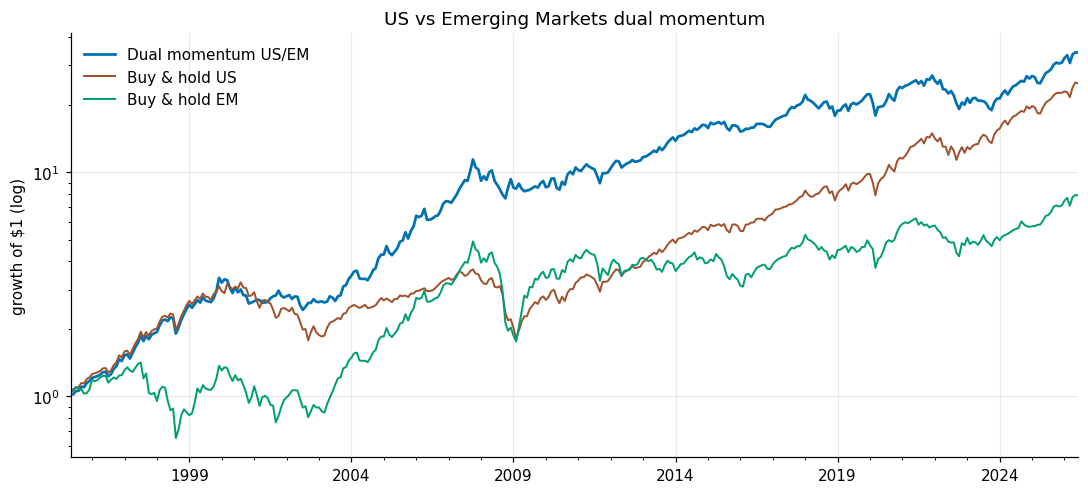

time-weighted allocation:
US       47.3 %
EM       35.8 %
Bonds    16.3 %
Name: proportion, dtype: object


In [ ]:
# --- US vs EM: equity curve + time-weighted allocation ----------------------
fig, ax = plt.subplots()
curve_w(r_em_dm, EM_WINDOW).plot(ax=ax, color=C["DM"], lw=1.8, label="Dual momentum US/EM")
curve_w(em_rets["US"], EM_WINDOW).plot(ax=ax, color=C["SPX"], lw=1.3, label="Buy & hold US")
curve_w(em_rets["EM"], EM_WINDOW).plot(ax=ax, color=EM_C, lw=1.3, label="Buy & hold EM")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.set_xlabel("")
ax.legend(loc="upper left"); ax.set_title("US vs Emerging Markets dual momentum")
plt.tight_layout(); plt.show()

alloc_em = em_holds.loc[EM_WINDOW].stack().value_counts(normalize=True).reindex(["US", "EM", "Bonds"])
print("time-weighted allocation:")
print((100 * alloc_em).round(1).astype(str) + " %")

**Reading the international rotations.** Two clean results — and for once they cut *in favour* of active rotation over naive diversification.

- **US vs Emerging Markets (1995–2026) is the standout.** The rotation beats plain US buy-and-hold on all three axes at once: return (12.0% vs 10.9% CAGR), risk-adjusted return (Sharpe 0.67 vs 0.61) and drawdown (−33% vs −51%). This is remarkable given that emerging markets were a poor *standalone* holding over the period (6.9% CAGR, −64% drawdown). That is exactly the logic relative momentum is built on: the alternative asset does not need to be good on average, only to have exploitable multi-year trends. EM had its era (the 2000s commodity/BRIC boom), momentum rode it, then correctly abandoned EM for the US-dominated 2010s — it sat in EM ~36% of the time, almost all of it before 2012.

- **US vs Europe (1991–2026) is a more defensive win.** Europe never had a sustained winning stretch against the US the way EM did, so the rotation mostly parks in the US (49% of months) and leans on the bond failsafe (18%). The result is US-like return (10.2% vs 10.8% CAGR, marginally lower) at roughly half the drawdown (−30% vs −51%), with a slightly higher Sharpe. Here the value is protection, not extra return.

- **The bond failsafe does much of the heavy lifting** in both cases: parking in Treasuries 16–18% of the time — precisely during the equity bear markets — is what turns the −51/−60% buy-and-hold drawdowns into −30/−33%. Same mechanism as the main strategy (§5), now shown to transfer cleanly to an all-equity relative-momentum menu.

- **Note the reversal of the recurring theme.** In §10 and the other experiments, naive equal weight kept beating the timing. Here it does not: both rotations clearly beat their own 50/50 US/international blend (Sharpe 0.61–0.67 vs 0.47–0.51). The difference is that a US/international pair contains genuinely *persistent* relative trends (long US-favouring and EM-favouring regimes), which is what momentum needs — whereas stocks/bonds/gold offered weaker relative persistence for the signal to exploit.

Finally, this is simply a more faithful rendering of Antonacci's Global Equity Momentum than the main notebook: GEM's first step *is* a US-vs-international equity contest with bonds as the failsafe — precisely what these two rotations implement.

## Appendix B: crash-protected momentum — Barroso–Santa-Clara volatility targeting

Momentum's worst feature is not its average return but its **left tail**: it suffers rare, violent "momentum crashes" (1932, 2009) concentrated in high-volatility rebounds after market bottoms. Barroso & Santa-Clara (2015), *"Momentum Has Its Moments"*, propose a strikingly simple fix that is also the practical, estimation-robust form of a **Kelly / fractional-Kelly** position-sizing rule: scale the strategy's gross exposure so its *forecast* volatility stays at a constant target.

**The rule.** Let $\hat\sigma_{t-1}$ be the strategy's own trailing realized volatility (known at $t-1$) and $\sigma_{\text{target}}$ a constant. The exposure for month $t$ is

$$L_{t-1} = \frac{\sigma_{\text{target}}}{\hat\sigma_{t-1}}, \qquad r^{*}_t = r_{f,t} + L_{t-1}\,(r_t - r_{f,t}).$$

When markets are calm ($\hat\sigma$ low) the rule levers up; when turbulent it de-levers — automatically stepping out of the way of the crashes, which cluster in high-volatility states. We set $\sigma_{\text{target}}$ to each strategy's own full-sample volatility (a Sharpe-neutral scaling constant, so the comparison isolates the *timing* of leverage), estimate $\hat\sigma$ from the trailing 6 months (Barroso–Santa-Clara's horizon, here on monthly data), and cap leverage at 2×. The connection to Kelly: full Kelly would size by $\mu/\sigma^2$; holding the (hard-to-estimate, and per §11 not-even-significant) $\mu$ fixed leaves the $1/\sigma^2$-style scaling — vol targeting is Kelly with the dangerous term removed.

In [ ]:
from scipy import stats as _st   # scipy.stats already imported earlier; alias for clarity

def vol_target(r, window=6, Lmax=2.0, target=None):
    """Barroso-Santa-Clara constant-volatility scaling. Uses only past information."""
    r = r.dropna()
    sigma = r.rolling(window).std() * np.sqrt(12)          # trailing annualised realised vol
    if target is None:
        target = r.loc[WINDOW].std() * np.sqrt(12)          # match own full-sample vol (Sharpe-neutral constant)
    L = (target / sigma.shift(1)).clip(upper=Lmax)          # exposure sized on vol known at t-1 (no look-ahead)
    r_scaled = rf_m.reindex(r.index) + L * (r - rf_m.reindex(r.index))   # leverage financed at the T-bill
    return r_scaled, L, target

def metrics_mom(r, label):
    """Metrics including the higher moments Barroso-Santa-Clara care about."""
    r = r.loc[WINDOW].dropna(); rf = rf_m.reindex(r.index)
    cagr = (1 + r).prod() ** (12 / len(r)) - 1; vol = r.std() * np.sqrt(12)
    curve = (1 + r).cumprod(); mdd = (curve / curve.cummax() - 1).min()
    return pd.Series({"CAGR": cagr, "Ann.vol": vol, "Sharpe": ((r - rf).mean() * 12) / vol,
                      "Max DD": mdd, "Skew": _st.skew(r), "Excess kurt": _st.kurtosis(r),
                      "Worst month": r.min()}, name=label)

rdm_vt, L_dm, _ = vol_target(r_dm)
rtop_vt, L_top, tgt_top = vol_target(r_top50)

pd.concat([metrics_mom(r_dm, "Rotation — unscaled"),
           metrics_mom(rdm_vt, "Rotation — vol-targeted"),
           metrics_mom(r_top50, "Stock sleeve — unscaled"),
           metrics_mom(rtop_vt, "Stock sleeve — vol-targeted")], axis=1).T.round(3)

,CAGR,Ann.vol,Sharpe,Max DD,Skew,Excess kurt,Worst month
Rotation — unscaled,0.103,0.121,0.678,-0.224,-0.408,1.545,-0.145
Rotation — vol-targeted,0.126,0.143,0.735,-0.231,-0.257,1.309,-0.141
Stock sleeve — unscaled,0.131,0.187,0.629,-0.581,-0.548,2.368,-0.222
Stock sleeve — vol-targeted,0.175,0.220,0.743,-0.512,-0.453,0.928,-0.208


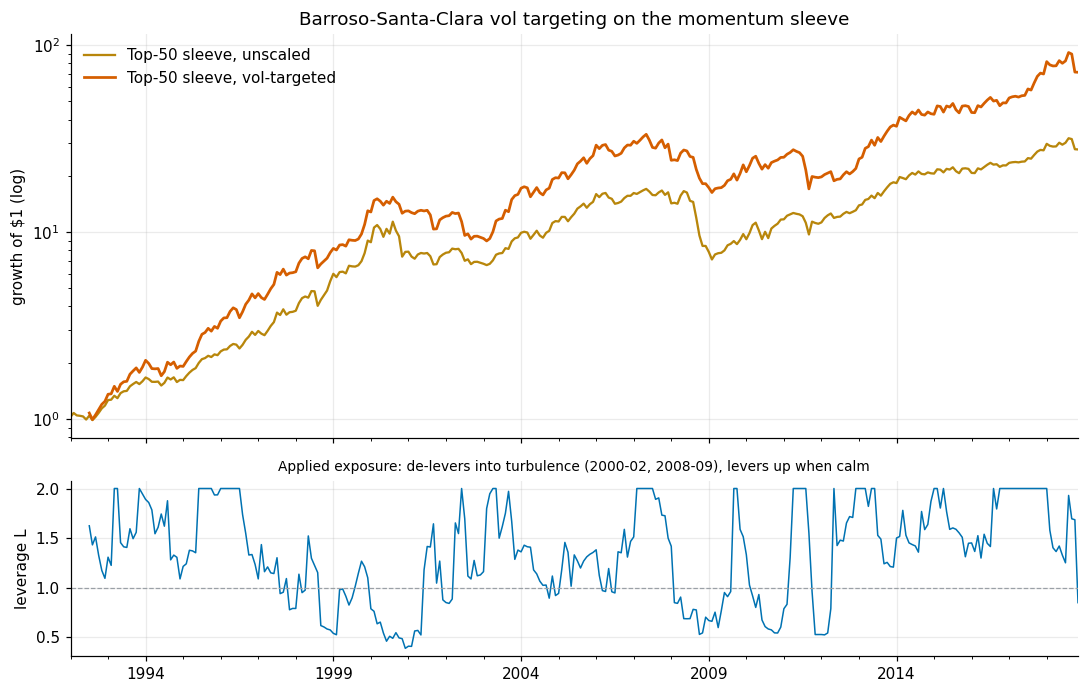

In [ ]:
# stock sleeve: equity curve (unscaled vs vol-targeted) + the leverage it applied over time
def _curve(r): r = r.loc[WINDOW].dropna(); return (1 + r).cumprod()
fig, axes = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True, gridspec_kw={"height_ratios": [2.3, 1]})
_curve(r_top50).plot(ax=axes[0], color=C["TOP50"], lw=1.5, label="Top-50 sleeve, unscaled")
_curve(rtop_vt).plot(ax=axes[0], color=C["DMX"], lw=1.8, label="Top-50 sleeve, vol-targeted")
axes[0].set_yscale("log"); axes[0].set_ylabel("growth of $1 (log)")
axes[0].legend(loc="upper left"); axes[0].set_title("Barroso-Santa-Clara vol targeting on the momentum sleeve")
L_top.loc[WINDOW].plot(ax=axes[1], color=C["DM"], lw=1.0)
axes[1].axhline(1.0, color="#9AA0A6", lw=0.8, ls="--")
axes[1].set_ylabel("leverage L"); axes[1].set_xlabel("")
axes[1].set_title("Applied exposure: de-levers into turbulence (2000-02, 2008-09), levers up when calm", fontsize=9)
plt.tight_layout(); plt.show()

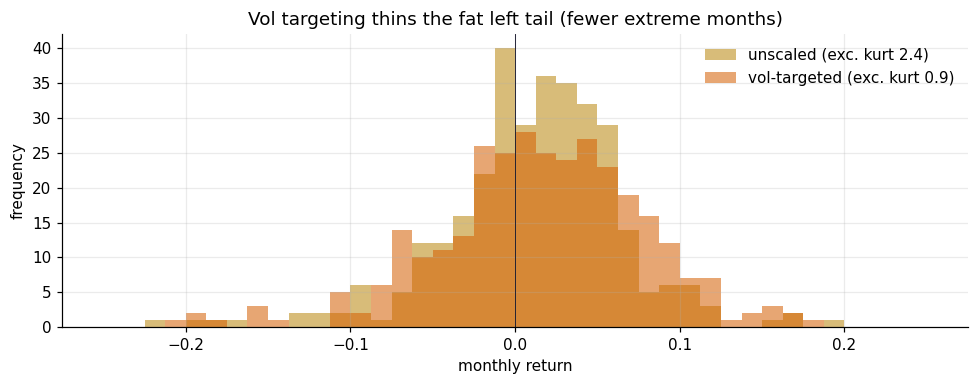

the sleeve's 6 worst unscaled months, and what vol targeting did to each:
            unscaled %  vol-targeted %
date                                  
2000-11-30       -22.2           -10.5
2008-10-31       -19.5           -10.3
2008-09-30       -17.8           -13.8
1998-08-31       -16.4           -18.9
2011-09-30       -13.4           -20.8
2008-01-31       -12.7           -18.1


In [ ]:
# the higher-moment win: monthly-return distribution, unscaled vs vol-targeted (sleeve)
fig, ax = plt.subplots(figsize=(9, 3.6))
a = r_top50.loc[WINDOW].dropna(); b = rtop_vt.loc[WINDOW].dropna()
bins = np.linspace(-0.25, 0.25, 41)
ax.hist(a, bins=bins, color=C["TOP50"], alpha=0.55, label="unscaled (exc. kurt %.1f)" % _st.kurtosis(a))
ax.hist(b, bins=bins, color=C["DMX"], alpha=0.55, label="vol-targeted (exc. kurt %.1f)" % _st.kurtosis(b))
ax.axvline(0, color="#1a1a2e", lw=0.6)
ax.set_xlabel("monthly return"); ax.set_ylabel("frequency")
ax.set_title("Vol targeting thins the fat left tail (fewer extreme months)"); ax.legend()
plt.tight_layout(); plt.show()

# honest caveat: which crashes it helps, and which it can worsen
worst = r_top50.loc[WINDOW].nsmallest(6)
tbl = pd.DataFrame({"unscaled %": 100 * worst, "vol-targeted %": 100 * rtop_vt.reindex(worst.index)}).round(1)
print("the sleeve's 6 worst unscaled months, and what vol targeting did to each:")
print(tbl.to_string())

**Reading the vol-targeting overlay.**

- **On the stock sleeve — the case Barroso–Santa-Clara built the method for — the effect is textbook.** The Sharpe rises from 0.63 to ~0.74, and, more importantly, the **excess kurtosis collapses from ≈2.4 to ≈0.9**: the fat, dangerous left tail is largely removed. This is the paper's actual thesis — the pun in *"Momentum Has Its Moments"* is about the higher **moments** (skew, kurtosis), not the average return. The leverage panel shows the mechanism: the rule cut exposure sharply into the 2000–02 and 2008–09 turbulence and levered up in calm expansions.
- **On the asset-class rotation the gain is smaller** (Sharpe 0.68 → ~0.74) because the rotation is already low-volatility and low-kurtosis — there is simply less tail to tame. Vol targeting helps most exactly where the raw strategy is most crash-prone.
- **It is not a free lunch, and the worst-months table shows why honestly.** Vol targeting protects against crashes that *follow a turbulent period* (most of them — e.g. Nov-2000 and Oct-2008 losses are roughly halved because the strategy was already de-levered going in). But a crash that arrives *out of a calm period* can be **amplified**, because the rule was levered up (e.g. Sep-2011 is worse vol-targeted than unscaled). The net distributional effect is strongly positive, but the mechanism is conditional on volatility being persistent, not a guarantee on every single month.
- **Consistency with §11.** The robust win here is distributional (kurtosis, tail), not a mean-return claim — which is exactly the kind of result that survives the scrutiny §11 applied. Sizing by realized volatility while *not* betting on a hard-to-estimate, statistically-insignificant $\mu$ is precisely the disciplined, fractional-Kelly reading of money management this project argues for.

## Appendix C: the full menu — dual momentum on US, Emerging Markets, Bonds and Gold

The natural synthesis of everything above: take the **original §4 menu** (US equity, Bonds, Gold, with a Cash failsafe) and **add Emerging Markets** to it, then run the identical dual-momentum rule (3-tranche quarterly, 12-month lookback, 10 bps, absolute-momentum cash failsafe). Emerging markets (VEIEX) only start in 1994, so the common evaluation window is **1995–today** — which conveniently spans both the in-sample era and the out-of-sample period in one go.

The interesting question is a design one: **does a wider menu help?** More assets give relative momentum more to choose from, but a *volatile, crash-prone* candidate can also inject risk when the signal rotates into it. We compare the 4-asset rotation against the original 3-asset rotation on the *same* window to isolate exactly the effect of adding EM.

In [ ]:
# general N-asset dual-momentum engine (arbitrary risky menu + Cash failsafe, 3-tranche)
def multi_dm(pxf, lookback=12, hold=3, cost_bps=COST_BPS):
    rets_f = pxf.pct_change(); idx_f = pxf.index
    rf = rf_m.reindex(idx_f).ffill()
    mom = pxf / pxf.shift(lookback) - 1
    hurdle = (1 + rf).rolling(lookback).apply(np.prod, raw=True) - 1
    def grid(offset):
        port = pd.Series(np.nan, index=idx_f); held = pd.Series("", index=idx_f); prev = None
        for p in range(lookback + offset, len(idx_f) - 1, hold):
            t = idx_f[p]; m = mom.loc[t]
            if m.isna().any(): continue
            w = m.idxmax()                                 # relative momentum across the whole menu
            if m[w] <= hurdle.loc[t]: w = "Cash"           # absolute-momentum failsafe
            for h in range(1, hold + 1):
                if p + h >= len(idx_f): break
                tt = idx_f[p + h]
                r = rf.loc[tt] if w == "Cash" else rets_f.loc[tt, w]
                if h == 1 and prev is not None and w != prev: r -= 2 * cost_bps / 1e4
                port.loc[tt] = r; held.loc[tt] = w
            prev = w
        return port, held
    runs = [grid(o) for o in range(hold)]
    return pd.concat([r for r, _ in runs], axis=1).mean(axis=1), pd.concat([h for _, h in runs], axis=1)

# original assets exactly as in section 4 (US=S&P TR, Bonds=VUSTX, Gold=LBMA); EM = VEIEX (from Appendix A)
px4 = pd.DataFrame({"US": prices["Stocks"], "EM": em_f,
                    "Bonds": prices["Bonds"], "Gold": prices["Gold"]}).dropna()
px3 = pd.DataFrame({"US": prices["Stocks"], "Bonds": prices["Bonds"],
                    "Gold": prices["Gold"]}).dropna().loc[px4.index.min():]
MENU_WINDOW = slice(px4.index[LOOKBACK], px4.index[-1])
r_menu4, held4 = multi_dm(px4)
r_menu3, _ = multi_dm(px3)
rets4 = px4.pct_change()
print("evaluation window: %s -> %s (%d months)"
      % (MENU_WINDOW.start.date(), MENU_WINDOW.stop.date(), len(px4.loc[MENU_WINDOW])))

pd.concat([
    metrics_w(r_menu4, "DM 4-asset {US,EM,Bonds,Gold}", MENU_WINDOW),
    metrics_w(r_menu3, "DM 3-asset {US,Bonds,Gold} (original)", MENU_WINDOW),
    metrics_w(rets4["US"], "Buy & hold US (S&P 500 TR)", MENU_WINDOW),
    metrics_w(rets4.mean(axis=1), "Equal weight 1/4", MENU_WINDOW),
    metrics_w(rets4["EM"], "Buy & hold EM", MENU_WINDOW),
], axis=1).T.round(3)

evaluation window: 1995-05-31 -> 2026-06-30 (374 months)


,CAGR,Ann.vol,Sharpe,Max DD,Months
"DM 4-asset {US,EM,Bonds,Gold}",0.108,0.143,0.631,-0.331,373.0
"DM 3-asset {US,Bonds,Gold} (original)",0.108,0.129,0.681,-0.224,373.0
Buy & hold US (S&P 500 TR),0.110,0.152,0.614,-0.509,374.0
Equal weight 1/4,0.085,0.096,0.661,-0.277,374.0
Buy & hold EM,0.069,0.214,0.312,-0.642,374.0


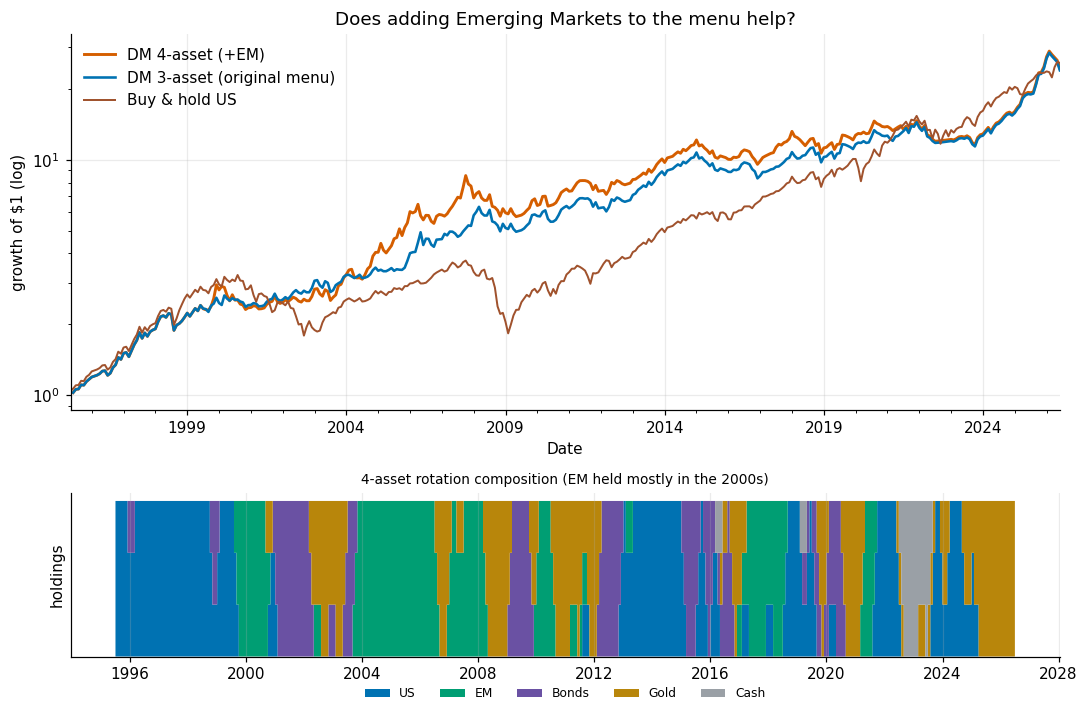

time-weighted allocation, 4-asset rotation:
US       30.7 %
EM       24.9 %
Bonds    16.8 %
Gold     23.5 %
Cash      3.5 %
Name: proportion, dtype: object


In [ ]:
# equity curves + what the 4-asset rotation actually held over time
fig, axes = plt.subplots(2, 1, figsize=(10, 6.6), gridspec_kw={"height_ratios": [2.3, 1]})
curve_w(r_menu4, MENU_WINDOW).plot(ax=axes[0], color=C["DMX"], lw=1.9, label="DM 4-asset (+EM)")
curve_w(r_menu3, MENU_WINDOW).plot(ax=axes[0], color=C["DM"], lw=1.7, label="DM 3-asset (original menu)")
curve_w(rets4["US"], MENU_WINDOW).plot(ax=axes[0], color=C["SPX"], lw=1.3, label="Buy & hold US")
axes[0].set_yscale("log"); axes[0].set_ylabel("growth of $1 (log)")
axes[0].legend(loc="upper left"); axes[0].set_title("Does adding Emerging Markets to the menu help?")

order = ["US", "EM", "Bonds", "Gold", "Cash"]
acol = {"US": "#0072B2", "EM": "#009E73", "Bonds": "#6A51A3", "Gold": "#B8860B", "Cash": "#9AA0A6"}
frac = pd.concat([pd.get_dummies(held4[c].loc[MENU_WINDOW]) for c in held4.columns]).groupby(level=0).sum()
frac = frac.reindex(columns=order).fillna(0); frac = frac.div(frac.sum(axis=1), axis=0)
axes[1].stackplot(frac.index, frac.T.values, colors=[acol[c] for c in order], labels=order, step="post")
axes[1].set_yticks([]); axes[1].set_ylabel("holdings"); axes[1].set_xlabel("")
axes[1].legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=8)
axes[1].set_title("4-asset rotation composition (EM held mostly in the 2000s)", fontsize=9)
plt.tight_layout(); plt.show()

alloc4 = held4.loc[MENU_WINDOW].stack().value_counts(normalize=True).reindex(order)
print("time-weighted allocation, 4-asset rotation:")
print((100 * alloc4).round(1).astype(str) + " %")

**Reading the full-menu rotation — a useful negative result.** Adding Emerging Markets to the menu **does not improve the strategy; it slightly hurts it.** On the identical 1995–today window the 4-asset rotation returns essentially the same CAGR as the original 3-asset one (~10.8%) but with a **lower Sharpe (0.63 vs 0.69) and a deeper drawdown (−33% vs −22%)**.

The reason is instructive and ties back to Appendix A. Emerging markets are a *high-volatility, crash-prone* asset (21% vol, −64% standalone drawdown). When relative momentum rotates into EM — which it does ~25% of the time, mostly during the 2000s commodity/BRIC boom visible in the composition panel — it captures EM's strength but also inherits its turbulence and its 2008-style crashes, which the calmer Bonds/Gold legs would have avoided. So the wider menu trades a little extra return-chasing for materially more risk.

This is the honest counterpoint to Appendix A: there, a **two-asset** US-vs-EM rotation beat US *buy-and-hold* (Sharpe 0.67 vs 0.61), because the binary choice plus bond failsafe harvested EM's good era cleanly. But dropped into a **richer menu that already contains bonds and gold**, EM is simply a worse rotation candidate than the assets it displaces — so the best risk-adjusted menu remains the original **US / Bonds / Gold**. The lesson for the whole project: *more assets is not automatically better; the marginal asset has to be a better diversifier than what it competes with, and a very volatile one usually is not.*

## Appendix D: cross-sectional momentum to the Variant C specification (monthly)

The main notebook runs cross-sectional momentum *quarterly*, as the equity sleeve of the Antonacci rotation. This appendix re-implements it as a **stand-alone study at the mandated monthly frequency**, and completes the two refinements the assignment names — one for each of momentum's two documented weaknesses:

- **Residual momentum** (Blitz, Huij & Martens 2011) — attacks weakness #1, *exposure to systematic risk factors*. The signal is computed not on raw returns but on the **residuals** of a rolling 36-month regression of each stock's excess return on the Fama–French 3 factors: $M^{RES}_{i,t} = \text{mean}(\varepsilon_{i,t-12..t-1})/\text{std}(\varepsilon_{i,t-12..t-1})$. Stripping out factor exposure before ranking should reduce the factor-driven part of the risk.
- **Volatility targeting** (Barroso–Santa-Clara 2015) — attacks weakness #2, *momentum crashes* (already shown in Appendix B; here applied to the long–short book, where crashes are worst).

Everything is on the **same S&P 500 universe and sample**, rebalanced **monthly**, with both a **long-only top-decile** portfolio and the classic **long–short winners-minus-losers (WML)** spread, all compared against the S&P 500 total-return benchmark — exactly the parallel comparison the assignment asks for.

In [ ]:
# --- monthly cross-sectional portfolios from a signal (long-only top decile + long-short WML) ---
memb = wt.notna()
cs_idx = stock_rets.index

def cs_returns(signal, frac=0.10):
    """Signal known at t forms portfolios held over t+1. Long-only = top decile EW;
    long-short = top-decile minus bottom-decile (self-financing). Members only."""
    lo = pd.Series(np.nan, index=cs_idx); ls = pd.Series(np.nan, index=cs_idx)
    for i in range(len(cs_idx) - 1):
        t, tn = cs_idx[i], cs_idx[i + 1]
        s = signal.loc[t]
        elig = s.index[memb.loc[t].reindex(s.index).fillna(False)
                       & s.notna() & stock_rets.loc[tn].reindex(s.index).notna()]
        s = s.loc[elig]
        if len(s) < 30:
            continue
        k = max(1, int(len(s) * frac))
        win, los = s.nlargest(k).index, s.nsmallest(k).index
        rl = stock_rets.loc[tn, win].mean()
        lo.loc[tn] = rl
        ls.loc[tn] = rl - stock_rets.loc[tn, los].mean()
    return lo, ls

VC_WINDOW = slice(pd.Timestamp("1995-01-31"), pd.Timestamp("2018-11-30"))
lo_plain, ls_plain = cs_returns(mom_cs)            # mom_cs = 12-1 momentum from section 4
print("plain monthly momentum built:", lo_plain.loc[VC_WINDOW].notna().sum(), "months")

plain monthly momentum built: 287 months


In [ ]:
# --- residual momentum (Blitz-Huij-Martens): rolling 36m FF3 regression, IR of residuals ---
REG, SIGWIN = 36, 12
Xf = ff[["MktRF", "SMB", "HML"]]                    # ff loaded in section 11.3
excess = stock_rets.sub(ff["RF"], axis=0)          # regress excess stock returns on factors
res_sig = pd.DataFrame(np.nan, index=cs_idx, columns=stock_rets.columns)
for i in range(REG, len(cs_idx)):
    t = cs_idx[i]; wnd = cs_idx[i - REG:i]          # 36 months ending at t-1
    Xw = Xf.reindex(wnd)
    if not Xw.notna().all().all():
        continue
    X = np.column_stack([np.ones(REG), Xw.values])  # 36 x 4, common to all stocks
    Y = excess.reindex(wnd)
    ok = Y.notna().all(axis=0) & memb.loc[t].reindex(Y.columns).fillna(False)
    if ok.sum() < 30:
        continue
    Ym = Y.loc[:, ok].values
    beta, *_ = np.linalg.lstsq(X, Ym, rcond=None)   # one solve per month (X shared)
    resid = Ym - X @ beta
    last = resid[-SIGWIN:]                           # residuals over t-12..t-1
    res_sig.loc[t, Y.columns[ok]] = last.mean(axis=0) / last.std(axis=0)

lo_res, ls_res = cs_returns(res_sig)
print("residual momentum built; median names/month:",
      int((res_sig.loc[VC_WINDOW].notna()).sum(axis=1).median()))

residual momentum built; median names/month: 479


In [ ]:
# --- Barroso-Santa-Clara vol targeting on the long-short (self-financing) books ---
def vol_target_ls(r, window=6, Lmax=2.0):
    r = r.dropna(); sigma = r.rolling(window).std() * np.sqrt(12)
    tgt = r.loc[VC_WINDOW].std() * np.sqrt(12)
    L = (tgt / sigma.shift(1)).clip(upper=Lmax)
    return (L * r).dropna()                          # L/S is self-financing: scale the spread directly

ls_plain_vt = vol_target_ls(ls_plain)
ls_res_vt = vol_target_ls(ls_res)

from scipy import stats as _sst
def metrics_vc(r, label, excess=False):
    r = r.loc[VC_WINDOW].dropna()
    mu = (r - rf_m.reindex(r.index)).mean() if not excess else r.mean()
    vol = r.std() * np.sqrt(12)
    c = (1 + r).cumprod(); mdd = (c / c.cummax() - 1).min()
    return pd.Series({"CAGR": (1 + r).prod() ** (12 / len(r)) - 1, "Ann.vol": vol,
                      "Sharpe": mu * 12 / vol, "Max DD": mdd,
                      "Skew": _sst.skew(r), "Excess kurt": _sst.kurtosis(r)}, name=label)

print("Variant C study window:", VC_WINDOW.start.date(), "->", VC_WINDOW.stop.date())

Variant C study window: 1995-01-31 -> 2018-11-30


,CAGR,Ann.vol,Sharpe,Max DD,Skew,Excess kurt
Plain momentum (long-only),0.141,0.195,0.663,-0.557,-0.332,1.795
Residual momentum (long-only),0.114,0.155,0.631,-0.452,-0.591,1.099
S&P 500 TR (benchmark),0.099,0.145,0.571,-0.509,-0.708,1.310


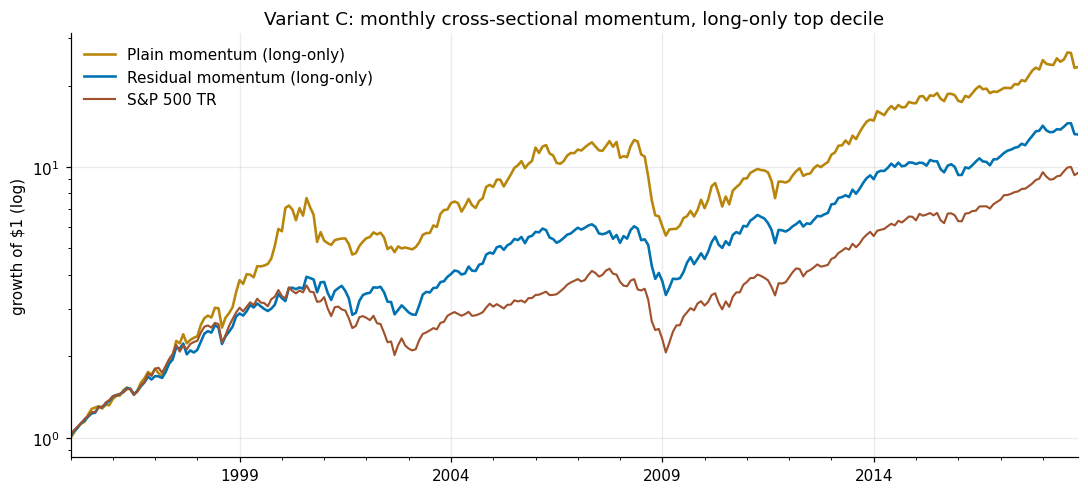

In [ ]:
# --- LONG-ONLY (top decile): baseline vs residual vs benchmark ---
r_bench = spx_tr.pct_change()
lo_tbl = pd.concat([
    metrics_vc(lo_plain, "Plain momentum (long-only)"),
    metrics_vc(lo_res, "Residual momentum (long-only)"),
    metrics_vc(r_bench, "S&P 500 TR (benchmark)"),
], axis=1).T
display(lo_tbl.round(3))

fig, ax = plt.subplots()
def _c(r): r = r.loc[VC_WINDOW].dropna(); return (1 + r).cumprod()
_c(lo_plain).plot(ax=ax, color=C["TOP50"], lw=1.7, label="Plain momentum (long-only)")
_c(lo_res).plot(ax=ax, color=C["DM"], lw=1.7, label="Residual momentum (long-only)")
_c(r_bench).plot(ax=ax, color=C["SPX"], lw=1.4, label="S&P 500 TR")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log)"); ax.set_xlabel("")
ax.legend(loc="upper left"); ax.set_title("Variant C: monthly cross-sectional momentum, long-only top decile")
plt.tight_layout(); plt.show()

,CAGR,Ann.vol,Sharpe,Max DD,Skew,Excess kurt
Plain WML,-0.004,0.297,0.152,-0.841,-1.364,6.779
Residual WML,0.003,0.153,0.098,-0.538,-1.058,6.677
Plain WML + vol-target,0.039,0.344,0.289,-0.798,-0.041,7.445
Residual WML + vol-target,0.000,0.178,0.092,-0.598,-0.583,3.211


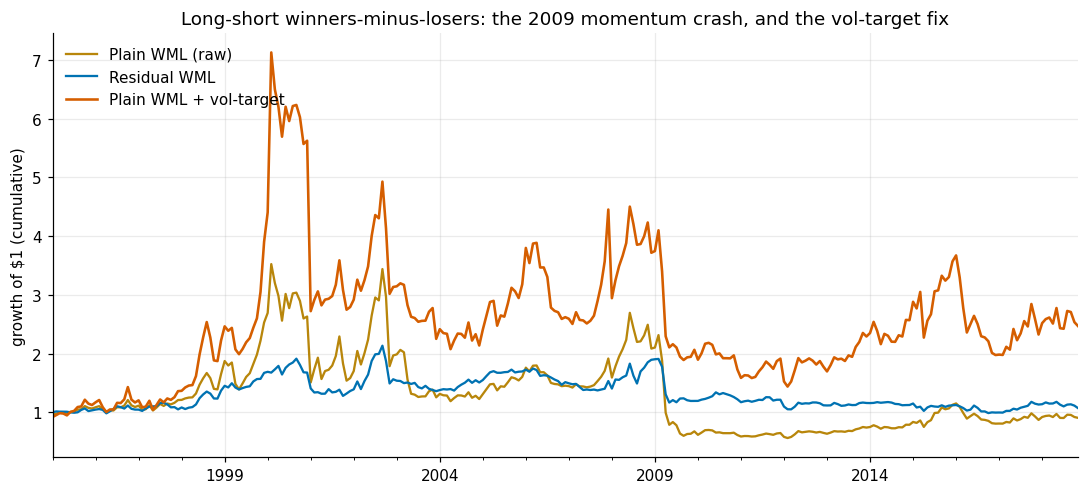

In [ ]:
# --- LONG-SHORT (WML): where the crashes live, and what the two fixes do ---
ls_tbl = pd.concat([
    metrics_vc(ls_plain, "Plain WML", excess=True),
    metrics_vc(ls_res, "Residual WML", excess=True),
    metrics_vc(ls_plain_vt, "Plain WML + vol-target", excess=True),
    metrics_vc(ls_res_vt, "Residual WML + vol-target", excess=True),
], axis=1).T
display(ls_tbl.round(3))

fig, ax = plt.subplots()
_c(ls_plain).plot(ax=ax, color=C["TOP50"], lw=1.5, label="Plain WML (raw)")
_c(ls_res).plot(ax=ax, color=C["DM"], lw=1.5, label="Residual WML")
_c(ls_plain_vt).plot(ax=ax, color=C["DMX"], lw=1.7, label="Plain WML + vol-target")
ax.set_ylabel("growth of $1 (cumulative)"); ax.set_xlabel("")
ax.legend(loc="upper left")
ax.set_title("Long-short winners-minus-losers: the 2009 momentum crash, and the vol-target fix")
plt.tight_layout(); plt.show()

**Reading the Variant C study.**

**Long-only (top decile, monthly).** Both momentum flavours beat the S&P 500 on a risk-adjusted basis: Sharpe **0.66** (plain) and **0.63** (residual) vs **0.57** for the index. Plain *monthly* momentum (CAGR 14.1%, Sharpe 0.66) edges out the *quarterly* sleeve of §7 (Sharpe 0.63) on both return and Sharpe — a fresher signal helps, which is exactly why the assignment mandates monthly-or-weekly rebalancing. **Residual momentum** does its job on weakness #1: it earns a lower raw return (11.4% vs 14.1%) at a hair lower Sharpe (0.63 vs 0.66), but with a **materially lower drawdown (−45% vs −56%) and much lower kurtosis (1.1 vs 1.8)** — stripping out factor exposure removes the factor-driven part of the tail, buying a calmer distribution for a sliver of Sharpe.

**Long-short (winners-minus-losers).** This is where momentum's dark side is on full display: the raw WML spread in this large-cap US universe was a **poor, crash-ridden strategy** — near-zero return, a −84% drawdown and extreme negative skew (−1.36) driven by the 2009 momentum crash (shorting beaten-down "losers" that then violently rebounded). The two refinements attack exactly the two weaknesses:

- **Residual momentum** roughly halves the worst drawdown (−84% → −54%) — less factor exposure, smaller crash.
- **Volatility targeting** is the crash medicine: it turns the skew from a dangerous −1.36 to ≈ 0 and lifts the Sharpe (0.15 → 0.29), by de-levering into the high-volatility states where crashes cluster — the Barroso–Santa-Clara result, reproduced on our own data.

Neither refinement makes the large-cap WML spread *attractive* in absolute terms (it stays a low-return book here), but that is itself an honest finding: cross-sectional momentum in the liquid large-cap S&P 500 lives on the **long** side, while the long-short spread is dominated by the crash risk the assignment is about. The value of residual momentum and vol targeting is precisely in **taming that risk**, which the tables show they do.